# AOCR — PoP Clustering con p-Mediana Capacitata

Il presente notebook affronta il problema della **localizzazione di Point-of-Presence (PoP)** modellato come un **problema di p-mediana capacitata**, un caso particolare dei *problemi di localizzazione*.

Nell'ottica dei problemi di localizzazione, l'obiettivo è definire le localizzazioni di *centri di servizio* (PoP) scelti da un insieme finito di candidati (*modello discreto*), per soddisfare la domanda dispersa sul territorio (utenti), minimizzando i **costi di afferenza** (latenza + costo economico di trasporto) nel rispetto di **vincoli di capacità**.

Il problema di **p-mediana** si ottiene quando i costi di localizzazione sono omogenei e si fissa a $p$ il numero di centri da aprire: la funzione obiettivo si riduce alla sola minimizzazione della somma dei costi di afferenza. L'aggiunta di vincoli di capacità sui centri di servizio porta alla variante **capacitated plant location**, in cui ogni centro può servire solo insiemi di clienti la cui domanda totale non supera la sua capacità.

**Metodi implementati**:
1. **MILP** — formulazione esatta in Programmazione Lineare Intera risolta con PuLP / CBC;
2. **Greedy-add** — euristica costruttiva di tipo *greedy* con assegnamento capacitato;
3. **Local Search (Teitz & Bart)** — euristica migliorativa con vicinato a 1-scambio (*vertex substitution*), adattata al vincolo di capacità;
4. **Tabu Search** — metaeuristica con lista tabù e criterio di aspirazione;
5. **Simulated Annealing** — metaeuristica con accettazione probabilistica e schema di raffreddamento;
6. **k-Means** — baseline con centroidi continui (centroidi *immaginari*, non vincolati ai candidati reali).

## 1 • Importazioni e dipendenze

In [1]:
import json
import math
import time
import hashlib
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from tqdm.auto import tqdm

# Stile seaborn globale
sns.set_theme(style="whitegrid", context="notebook", palette="Set2")

# k-Means baseline
from sklearn.cluster import KMeans

# Solver MILP 
import pulp

/Users/l.catello/Library/Mobile Documents/com~apple~CloudDocs/Magistrale Ingegneria Informatica/Algoritmi di Ottimizzazione Combinatoria e su Rete/aocr-capacitated-pmedian/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 • Configurazione e caricamento dati

I parametri sperimentali (numero utenti, valori di $p$, seed, pesi obiettivo, capacità) sono centralizzati nel dizionario `CONFIG`.

I dati di input — **anchor delle città utente** e **candidati PoP** — vengono letti da file JSON nella cartella `data/`.

In [2]:
# ── Parametri sperimentali ──────────────────────────────────────────
CONFIG = {
    'n_users': [120, 300, 600, 1000],          # dimensioni delle istanze (nodi di domanda)
    'p_values': [3, 5, 8, 10, 13, 15, 18, 20], # numero di centri di servizio da aprire
    'seeds': [0, 1, 2],                        # seed per riproducibilità
    'latency_per_km_ms': 0.02,                 # componente latenza del costo di afferenza
    'cost_per_km_eur': 0.03,                   # componente economica del costo di afferenza
    'objective_weights': {                     # pesi nella funzione obiettivo
        'latency': 1.0,
        'cost': 1.0,
    },
    'capacity': {                              # vincoli di capacità sui centri di servizio
        'multiplier': 1.3,                     # slack rispetto alla domanda media
        'heterogeneity_factor': 0.2,           # variazione percentuale massima eterogenea
    },
    'kmeans': {                                # parametri baseline k-Means
        'max_iter': 50,
        'n_init': 3,
    },
    'cache': {                                 # caching risultati
        'use_cache': True,                      # usa CSV se presente
        'force_recompute': False,               # ignora cache e ricalcola
        'dir': 'results/cache',                 # cartella cache
    },
}

# ── Caricamento dati di input ──────────────────────────────────────
# I = insieme dei siti candidati per i centri di servizio (PoP)
# J = insieme dei nodi di domanda (utenti, città anchors)
user_anchors_path = Path('data/user_anchors.json')
pop_candidates_path = Path('data/pop_candidates.json')

with user_anchors_path.open('r', encoding='utf-8') as f:
    USER_ANCHORS = json.load(f)

with pop_candidates_path.open('r', encoding='utf-8') as f:
    POP_CANDIDATES = json.load(f)

# Raggio di jitter per la generazione nodi di domanda (km) e range domanda d_j
USER_JITTER_KM = 120.0
DEMAND_MIN = 1.0
DEMAND_MAX = 5.0

# Coordinate dei candidati centri di servizio come array NumPy
pop_coords = np.array([[c['lat'], c['lon']] for c in POP_CANDIDATES], dtype=float)
print(f"Candidati centri di servizio (PoP) caricati: {len(pop_coords)}")

Candidati centri di servizio (PoP) caricati: 20


Le istanze utenti generate vengono salvate automaticamente in `data/generated/` e riutilizzate se già presenti, garantendo la **riproducibilità** degli esperimenti. Inoltre, Il file `data/index.json` funge da **registro dei dataset**: tiene traccia di ogni istanza generata.

## 3 • Funzioni di utilità

Funzioni condivise tra i vari metodi risolutivi:

- **`haversine_matrix`** — matrice delle distanze geodetiche (formula di Haversine). Nei problemi di localizzazione, la misura della distanza tra punti di domanda e potenziali centri di servizio è un aspetto fondamentale. In questo contesto si utilizza la distanza geodetica (approssimazione della metrica euclidea $k=2$ su superficie sferica).
- **`sample_users`** — generazione / caricamento delle istanze utenti (nodi di domanda $j \in J$).
- **`build_capacities`** — calcolo delle capacità $m_i$ per ciascun candidato PoP (centri di servizio $i \in I$).
- **`effective_cost_per_km`** — **costo di afferenza** per km, combinazione pesata di latenza e costo economico di trasporto.

In [3]:
EARTH_RADIUS_KM = 6371.0


def haversine_matrix(coords_a: np.ndarray, coords_b: np.ndarray) -> np.ndarray:
    """Matrice delle distanze geodetiche (Haversine) tra due insiemi di punti.

    Args:
        coords_a: Array (n, 2) con colonne [lat, lon] in gradi — nodi di domanda.
        coords_b: Array (m, 2) con colonne [lat, lon] in gradi — candidati centri.

    Returns:
        Matrice (n, m) di distanze in chilometri.
    """
    lat1 = np.deg2rad(coords_a[:, 0])[:, None]
    lon1 = np.deg2rad(coords_a[:, 1])[:, None]
    lat2 = np.deg2rad(coords_b[:, 0])[None, :]
    lon2 = np.deg2rad(coords_b[:, 1])[None, :]

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c


def sample_users(n_users: int, seed: int, generated_dir: Path = Path('data/generated')):
    """Carica un'istanza di nodi di domanda o ne genera una nuova se non esiste già.

    Ogni utente viene posizionato con jitter casuale attorno a una città-ancora
    scelta uniformemente. La domanda d_j è campionata U(DEMAND_MIN, DEMAND_MAX).
    I dataset generati vengono salvati in `generated_dir` e registrati in
    `data/index.json`.

    Args:
        n_users: Numero di nodi di domanda da generare.
        seed: Seed per il generatore casuale.
        generated_dir: Cartella di destinazione.

    Returns:
        Tupla (coords, demands) con coordinate (n, 2) e domande d_j (n,).
    """
    generated_dir.mkdir(parents=True, exist_ok=True)
    path = generated_dir / f"users_n{n_users}_seed{seed}.json"

    # Se il file esiste già, ricarica direttamente
    if path.exists():
        data = json.loads(path.read_text(encoding='utf-8'))
        coords = np.array([[d['lat'], d['lon']] for d in data], dtype=float)
        demands = np.array([d['demand'] for d in data], dtype=float)
        return coords, demands

    # Generazione nuova istanza di nodi di domanda
    rng = np.random.default_rng(seed)
    anchor_idx = rng.integers(0, len(USER_ANCHORS), size=n_users)
    coords = np.zeros((n_users, 2), dtype=float)

    for i, idx in enumerate(anchor_idx):
        base = USER_ANCHORS[int(idx)]
        r = USER_JITTER_KM * np.sqrt(rng.random())
        theta = 2 * np.pi * rng.random()
        dlat = (r * np.cos(theta)) / 111.0
        lat_rad = math.radians(base['lat'])
        dlon = (r * np.sin(theta)) / (111.0 * math.cos(lat_rad))
        coords[i, 0] = base['lat'] + dlat
        coords[i, 1] = base['lon'] + dlon

    demands = rng.uniform(DEMAND_MIN, DEMAND_MAX, size=n_users)

    # Salvataggio su disco
    data = [
        {"lat": float(coords[i, 0]), "lon": float(coords[i, 1]), "demand": float(demands[i])}
        for i in range(n_users)
    ]
    path.write_text(json.dumps(data, indent=2), encoding='utf-8')

    # Aggiornamento registro dataset
    index_path = Path('data/index.json')
    index_data = json.loads(index_path.read_text(encoding='utf-8'))

    record = {
        'file': str(path.as_posix()),
        'n_users': n_users,
        'seed': seed,
        'count': len(data),
    }
    datasets = [d for d in index_data.get('datasets', []) if d.get('file') != record['file']]
    datasets.append(record)
    index_data['datasets'] = sorted(datasets, key=lambda d: (d.get('n_users', 0), d.get('seed', 0)))
    index_path.write_text(json.dumps(index_data, indent=2), encoding='utf-8')

    return coords, demands


def build_capacities(demands: np.ndarray, p: int, seed: int) -> np.ndarray:
    """Calcola le capacità m_i dei candidati centri di servizio.

    Nel problema di capacitated plant location, ogni centro di servizio ha
    una capacità m_i: una volta aperto, può servire solo insiemi di clienti
    la cui domanda totale non supera m_i. La capacità base è calcolata come
    ``multiplier * (domanda_totale / p)`` con eterogeneità casuale tra i centri.

    Args:
        demands: Vettore delle domande d_j degli utenti.
        p: Numero di centri di servizio da aprire.
        seed: Seed per la componente stocastica.

    Returns:
        Array di capacità m_i, uno per ciascun candidato.
    """
    cap_cfg = CONFIG['capacity']
    total = float(np.sum(demands))
    base = cap_cfg['multiplier'] * (total / p)
    caps = np.full(len(pop_coords), base, dtype=float)

    # Capacità eterogenee: ogni centro ha una capacità variabile
    rng = np.random.default_rng(seed + 12345)
    delta = rng.uniform(
        -cap_cfg['heterogeneity_factor'],
        cap_cfg['heterogeneity_factor'],
        size=len(pop_coords),
    )
    caps = np.maximum(caps * (1.0 + delta), 1e-6)

    return caps


def effective_cost_per_km() -> float:
    """Restituisce il costo di afferenza per km.

    Nei problemi di localizzazione, i costi variabili (costi di afferenza)
    sono i costi di accesso al servizio. Qui il costo è calcolato come
    combinazione pesata di latenza e costo economico di trasporto:
        w_latency * latency_per_km + w_cost * cost_per_km

    Returns:
        Costo di afferenza per chilometro (scalare).
    """
    w = CONFIG['objective_weights']
    return w['latency'] * CONFIG['latency_per_km_ms'] + w['cost'] * CONFIG['cost_per_km_eur']

**Costo di afferenza**: nei problemi di localizzazione, i *costi variabili* o *costi di afferenza* rappresentano i costi di accesso al servizio da parte dei clienti. In questo progetto il costo di afferenza è proporzionale alla distanza in km, trasformata in un costo complessivo che combina latenza (ms/km) e costo economico di trasporto (€/km).

## 4 • MILP — p-Mediana capacitata (PuLP / CBC)

Il problema viene formulato come un **programma lineare intero** (PLI), risolto esattamente tramite il solutore CBC. La formulazione segue il modello classico della *p-mediana capacitata*, caso particolare del *capacitated plant location* in cui i costi fissi di localizzazione sono omogenei e il numero $p$ di centri da aprire è fissato.

### Dati del problema
- $c_{ij}$: costo di afferenza del cliente $j$ al centro di servizio $i$
- $d_j$: domanda del cliente $j$
- $m_i$: capacità del centro di servizio $i$
- $p$: numero di centri da attivare

### Variabili decisionali
- $y_i \in \{0,1\}$ — vale 1 se nel sito $i$ è localizzato un centro di servizio, 0 altrimenti
- $x_{ij} \in \{0,1\}$ — vale 1 se il cliente $j$ afferisce al centro di servizio $i$, 0 altrimenti

### Formulazione

$$\min \sum_{i} \sum_{j} d_j \cdot c_{ij} \cdot x_{ij}$$

soggetta a:

$$\sum_{i} x_{ij} = 1 \quad \forall\, j \quad \text{(ogni cliente assegnato a un unico centro)}$$

$$x_{ij} \le y_i \quad \forall\, i,j \quad \text{(assegnamento solo a centri aperti)}$$

$$\sum_{i} y_i = p \quad \text{(esattamente } p \text{ centri attivi)}$$

$$\sum_{j} d_j \cdot x_{ij} \le m_i \cdot y_i \quad \forall\, i \quad \text{(vincolo di capacità)}$$

Quando le dimensioni del problema di PLI crescono, anche i migliori solutori possono impiegare molto tempo per dimostrare l'ottimalità. Per questo motivo si affiancano alla soluzione esatta delle **euristiche** che forniscono soluzioni ammissibili di buona qualità in tempi più contenuti.

In [4]:
def solve_pmedian_pulp(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
) -> dict:
    """Risolve il problema di p-mediana capacitata tramite PLI (PuLP / CBC).

    Formulazione classica dei problemi di localizzazione: si determinano
    simultaneamente i siti in cui localizzare i centri di servizio e
    l'allocazione della domanda a ogni sito.

    Variabili decisionali:
        y_j = 1 se nel sito j è localizzato un centro di servizio, 0 altrimenti.
        x_ij = 1 se il cliente i afferisce al centro j, 0 altrimenti.

    Args:
        dist_cost: Matrice dei costi di afferenza c_ij (n_clients, n_candidates).
        demands: Domanda d_j degli utenti (n_clients,).
        p: Numero di centri di servizio da attivare.
        capacities: Capacità m_i per ciascun candidato.

    Returns:
        Dizionario con chiavi: status, objective, open, assign, runtime.
    """
    n_clients, n_candidates = dist_cost.shape

    prob = pulp.LpProblem('pmedian', pulp.LpMinimize)
    y = pulp.LpVariable.dicts('y', range(n_candidates), 0, 1, cat=pulp.LpBinary)
    x = pulp.LpVariable.dicts('x', (range(n_clients), range(n_candidates)), 0, 1, cat=pulp.LpBinary)

    # Vincolo di assegnamento: ogni cliente afferisce a un unico centro
    for i in range(n_clients):
        prob += pulp.lpSum(x[i][j] for j in range(n_candidates)) == 1

    # Vincolo di apertura: un cliente può afferire solo a centri aperti
    for i in range(n_clients):
        for j in range(n_candidates):
            prob += x[i][j] <= y[j]

    # Vincolo di cardinalità: esattamente p centri di servizio attivi
    prob += pulp.lpSum(y[j] for j in range(n_candidates)) == p

    # Vincolo di capacità: domanda totale afferente ≤ capacità del centro
    for j in range(n_candidates):
        prob += (
            pulp.lpSum(demands[i] * x[i][j] for i in range(n_clients))
            <= capacities[j] * y[j]
        )

    # Funzione obiettivo: min Σ_i Σ_j d_i * c_ij * x_ij
    prob += pulp.lpSum(
        demands[i] * dist_cost[i, j] * x[i][j]
        for i in range(n_clients)
        for j in range(n_candidates)
    )

    solver = pulp.PULP_CBC_CMD(msg=False)
    start = time.perf_counter()
    prob.solve(solver)
    runtime = time.perf_counter() - start

    status = pulp.LpStatus[prob.status]
    if status != 'Optimal':
        raise RuntimeError(f"solve_pmedian_pulp: CBC status={status}")
    open_hubs = [j for j in range(n_candidates) if pulp.value(y[j]) > 0.5]

    # Ricostruzione dell'assegnamento clienti → centri
    assign = np.empty(n_clients, dtype=int)
    for i in range(n_clients):
        vals = np.array([pulp.value(x[i][j]) for j in range(n_candidates)], dtype=float)
        assign[i] = int(np.argmax(vals))

    # Calcolo del costo totale di afferenza
    obj = float(np.sum(demands * dist_cost[np.arange(n_clients), assign]))

    return {
        'status': status,
        'objective': obj,
        'open': open_hubs,
        'assign': assign,
        'runtime': runtime,
    }

## 5 • Euristica Greedy-add con assegnamento capacitato

Gli **algoritmi euristici** (o approssimati) ricercano una buona soluzione del problema, non necessariamente ottima, con tempi di calcolo più contenuti rispetto agli approcci esatti. Tra le due classi principali — *algoritmi costruttivi* e *algoritmi migliorativi* — l'euristica qui implementata è di tipo **costruttivo (greedy)**.

Un **algoritmo greedy** seleziona ad ogni iterazione l'elemento che, a quel passo, risulta più conveniente senza preoccuparsi della struttura complessiva della soluzione. L'algoritmo costruisce una sequenza di *soluzioni parziali* (sottoinsiemi $T$ dell'insieme base $B$) fino ad arrivare a una soluzione ammissibile.

### 5a • Greedy-add per la p-mediana

L'euristica **greedy-add** costruisce iterativamente l'insieme dei centri di servizio aperti, selezionando un sito per volta. Ad ogni iterazione viene aggiunto il candidato la cui attivazione massimizza la **diminuzione del costo di afferenza**. Una volta attivato, il sito rimane tale fino alla fine (l'algoritmo non ritorna indietro sulle decisioni già effettuate). L'algoritmo termina quando sono stati aperti esattamente $p$ centri.

L'**assegnamento capacitato** rispetta i vincoli di capacità $m_i$: gli utenti vengono ordinati per domanda decrescente e assegnati al PoP aperto più vicino con capacità residua sufficiente.

In [5]:
def greedy_add(dist_cost: np.ndarray, demands: np.ndarray, p: int) -> list[int]:
    """Euristica costruttiva greedy-add per la selezione di p centri di servizio.

    Args:
        dist_cost: Matrice dei costi di afferenza c_ij (n_clients, n_candidates).
        demands: Domanda d_j degli utenti (n_clients,).
        p: Numero di centri di servizio da attivare.

    Returns:
        Lista degli indici dei siti selezionati (centri di servizio aperti).
    """
    n_clients, n_candidates = dist_cost.shape
    open_hubs: list[int] = []
    best_dist = np.full(n_clients, np.inf)

    for _ in range(p):
        best_obj = float('inf')
        best_j = None
        best_new = None

        for j in range(n_candidates):
            if j in open_hubs:
                continue
            # Valuta il costo di afferenza se il candidato j venisse attivato
            new_dist = np.minimum(best_dist, dist_cost[:, j])
            obj = float(np.sum(demands * new_dist))
            if obj < best_obj:
                best_obj = obj
                best_j = j
                best_new = new_dist

        if best_j is None:
            break
        open_hubs.append(best_j)
        best_dist = best_new

    return open_hubs


def assign_with_capacity(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    open_hubs: list[int],
    capacities: np.ndarray,
) -> tuple[np.ndarray, bool]:
    """Assegna i clienti ai centri di servizio aperti rispettando i vincoli di capacità.

    I clienti vengono processati in ordine di domanda decrescente e assegnati
    al centro aperto più vicino che abbia capacità residua sufficiente.
    Questo approccio greedy sull'assegnamento corrisponde alla risoluzione
    euristica del sottoproblema del trasporto (analogo al capacitated plant
    location, dove una volta scelti i siti occorre risolvere un problema
    di trasporto per le afferenze).

    Args:
        dist_cost: Matrice dei costi di afferenza c_ij (n_clients, n_candidates).
        demands: Domanda d_j degli utenti.
        open_hubs: Indici dei centri di servizio aperti.
        capacities: Capacità m_i dei candidati.

    Returns:
        Tupla (assign, feasible): vettore di assegnamento e flag di ammissibilità.
    """
    n_clients = dist_cost.shape[0]
    assign = np.full(n_clients, -1, dtype=int)
    remaining = capacities[open_hubs].astype(float).copy()
    order = np.argsort(-demands)

    for i in order:
        d = demands[i]
        dists = dist_cost[i, open_hubs]
        for idx in np.argsort(dists):
            if remaining[idx] >= d:
                remaining[idx] -= d
                assign[i] = open_hubs[idx]
                break
        if assign[i] == -1:
            return assign, False

    return assign, True


def greedy_solution(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
) -> dict:
    """Soluzione completa: greedy-add (costruzione) + assegnamento capacitato.

    Combinazione di euristica costruttiva greedy per la scelta dei siti e
    assegnamento greedy dei clienti ai centri aperti con rispetto dei vincoli
    di capacità.

    Args:
        dist_cost: Matrice dei costi di afferenza.
        demands: Domanda degli utenti.
        p: Numero di centri di servizio da attivare.
        capacities: Capacità dei candidati.

    Returns:
        Dizionario con: status, objective, open, assign, runtime, feasible.
    """
    start = time.perf_counter()
    open_hubs = greedy_add(dist_cost, demands, p)

    assign, feasible = assign_with_capacity(dist_cost, demands, open_hubs, capacities)

    if feasible:
        obj = float(np.sum(demands * dist_cost[np.arange(len(demands)), assign]))
    else:
        obj = float('inf')

    return {
        'status': 'greedy',
        'objective': obj,
        'open': open_hubs,
        'assign': assign,
        'runtime': time.perf_counter() - start,
        'feasible': feasible,
    }


### 5b • Ricerca Locale — Algoritmo di Teitz e Bart

Tra le euristiche di **ricerca locale** (o *migliorative*), l'**algoritmo di Teitz e Bart** è il metodo classico per il problema di p-mediana (non capacitato). In questo notebook lo si usa come schema di 1-scambio (*vertex substitution*) adattato al caso capacitato: dopo ogni swap si ricalcola l'assegnamento rispettando i vincoli di capacità e si accetta la mossa solo se la soluzione resta ammissibile. A differenza dell'euristica greedy, che costruisce la soluzione un elemento alla volta senza mai tornare indietro, la ricerca locale parte da una soluzione ammissibile e ne esplora il **vicinato** alla ricerca di soluzioni miglioranti fino a un ottimo locale (non necessariamente globale).


#### Schema dell'algoritmo
1. Si parte da una soluzione iniziale $S$ (insieme di $p$ centri aperti) — qui ottenuta con la greedy-add.
2. Si definisce una **mossa** come lo scambio (*swap*) di un centro aperto $i \in S$ con un candidato chiuso $j \notin S$.
3. Il **vicinato** $N(S)$ è l'insieme di tutte le soluzioni ottenibili con un singolo swap: $|N(S)| = p \cdot (|I| - p)$.
4. Si valuta ogni mossa ammissibile (capacità rispettate) e si seleziona quella che produce la **massima diminuzione** del costo di afferenza.
5. Si itera finché nessuno swap produce un miglioramento → la soluzione corrente è un **ottimo locale**.

In [6]:
def local_search_swap(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
    initial_open: list[int],
    max_iter: int = 500,
) -> dict:
    """Ricerca locale (in stile Teitz & Bart) per la p-mediana capacitata.

    Euristica migliorativa basata su *vertex substitution* (1-interchange):
    ad ogni iterazione si valutano tutte le possibili mosse di scambio
    (swap) tra un centro aperto e un candidato chiuso. Si seleziona lo swap
    con il miglior miglioramento (best improvement) e si itera fino a
    raggiungere un ottimo locale (nessuno swap migliora la soluzione).

    Args:
        dist_cost: Matrice dei costi di afferenza c_ij (n_clients, n_candidates).
        demands: Domanda d_j degli utenti (n_clients,).
        p: Numero di centri di servizio da attivare.
        capacities: Capacità m_i per ciascun candidato.
        initial_open: Soluzione iniziale (lista di p indici).
        max_iter: Numero massimo di iterazioni.

    Returns:
        Dizionario con: status, objective, open, assign, runtime, feasible, iterations.
    """
    start = time.perf_counter()
    n_clients, n_candidates = dist_cost.shape

    current_open = list(initial_open)
    if len(current_open) != p:
        raise ValueError("local_search_swap: initial_open deve avere lunghezza p")
    if len(set(current_open)) != p:
        raise ValueError("local_search_swap: initial_open contiene duplicati")
    if any((hub < 0 or hub >= n_candidates) for hub in current_open):
        raise ValueError("local_search_swap: initial_open contiene indici fuori range")

    def evaluate(hubs):
        """Calcola obiettivo e assegnamento per un dato insieme di centri."""
        assign, feasible = assign_with_capacity(dist_cost, demands, hubs, capacities)
        if not feasible:
            return float('inf'), assign, False
        obj = float(np.sum(demands * dist_cost[np.arange(n_clients), assign]))
        return obj, assign, feasible

    current_obj, current_assign, current_feasible = evaluate(current_open)
    iterations = 0

    for _ in range(max_iter):
        iterations += 1
        best_obj = current_obj
        best_swap = None  # (idx_in_open, candidate_to_add)

        # Esplora il vicinato: tutti gli swap possibili
        closed = [j for j in range(n_candidates) if j not in current_open]
        for idx_out, hub_out in enumerate(current_open):
            for hub_in in closed:
                # Nuovo insieme di centri con lo swap
                new_open = current_open.copy()
                new_open[idx_out] = hub_in
                obj, _, feas = evaluate(new_open)
                if feas and obj < best_obj:
                    best_obj = obj
                    best_swap = (idx_out, hub_in)

        if best_swap is None:
            # Ottimo locale raggiunto: nessuno swap migliora la soluzione
            break

        # Applica lo swap migliore
        idx_out, hub_in = best_swap
        current_open[idx_out] = hub_in
        current_obj, current_assign, current_feasible = evaluate(current_open)

    return {
        'status': 'local_search',
        'objective': current_obj,
        'open': current_open,
        'assign': current_assign,
        'runtime': time.perf_counter() - start,
        'feasible': current_feasible,
        'iterations': iterations,
    }


### 5c • Tabu Search

La **Tabu Search** è una metaeuristica che estende la ricerca locale per sfuggire agli **ottimi locali**. L'idea chiave è che, anziché fermarsi quando nessuna mossa nel vicinato migliora la soluzione, l'algoritmo accetta anche mosse peggioranti (la *migliore disponibile*) e utilizza una **lista tabù** per impedire il ritorno a soluzioni recentemente visitate.

### Componenti della Tabu Search
1. **Mossa**: swap di un centro aperto $i \in S$ con un candidato chiuso $j \notin S$ (come in Teitz & Bart).
2. **Lista tabù**: struttura FIFO di lunghezza fissa (`tabu_tenure`). Memorizza le coppie $(i_{\text{out}}, j_{\text{in}})$ per impedire il reverse swap nelle iterazioni successive.
3. **Criterio di aspirazione**: se una mossa tabù conduce a una soluzione migliore della *best-so-far*, viene comunque accettata (aspiration by objective).
4. **Criterio d'arresto**: numero massimo di iterazioni senza miglioramento della soluzione globale (`max_no_improve`).

In [7]:
def tabu_search(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
    initial_open: list[int],
    tabu_tenure: int = 7,
    max_iter: int = 200,
    max_no_improve: int = 50,
) -> dict:
    """Tabu Search per la p-mediana capacitata.

    Metaeuristica basata su ricerca locale con lista tabù. La mossa è lo
    swap di un centro aperto con un candidato chiuso (1-interchange).
    La lista tabù (FIFO) impedisce di tornare su coppie di swap recenti,
    a meno che la mossa soddisfi il *criterio di aspirazione* (migliora
    la best-so-far).

    Args:
        dist_cost: Matrice dei costi di afferenza c_ij (n_clients, n_candidates).
        demands: Domanda d_j degli utenti.
        p: Numero di centri di servizio da attivare.
        capacities: Capacità m_i dei candidati.
        initial_open: Soluzione iniziale (lista di p indici).
        tabu_tenure: Dimensione della lista tabù FIFO.
        max_iter: Numero massimo di iterazioni totali.
        max_no_improve: Iterazioni senza miglioramento prima di terminare.

    Returns:
        Dizionario con: status, objective, open, assign, runtime, feasible, iterations.
    """
    from collections import deque

    start = time.perf_counter()
    n_clients, n_candidates = dist_cost.shape

    current_open = list(initial_open)
    if len(current_open) != p:
        raise ValueError("tabu_search: initial_open deve avere lunghezza p")
    if len(set(current_open)) != p:
        raise ValueError("tabu_search: initial_open contiene duplicati")
    if any((hub < 0 or hub >= n_candidates) for hub in current_open):
        raise ValueError("tabu_search: initial_open contiene indici fuori range")

    def evaluate(hubs):
        assign, feasible = assign_with_capacity(dist_cost, demands, hubs, capacities)
        if not feasible:
            return float('inf'), assign, False
        obj = float(np.sum(demands * dist_cost[np.arange(n_clients), assign]))
        return obj, assign, feasible

    current_obj, current_assign, current_feasible = evaluate(current_open)

    # Inizializzazione best-so-far
    best_obj = current_obj
    best_open = list(current_open)
    best_assign = current_assign.copy()
    best_feasible = current_feasible

    # Lista tabù: FIFO di coppie (hub_rimosso, hub_aggiunto)
    tabu_list: deque = deque(maxlen=tabu_tenure)
    no_improve_count = 0
    iterations = 0

    for _ in range(max_iter):
        iterations += 1
        best_move_obj = float('inf')
        best_move = None  # (idx_in_open, hub_in)

        closed = [j for j in range(n_candidates) if j not in current_open]

        for idx_out, hub_out in enumerate(current_open):
            for hub_in in closed:
                # Verifica se la mossa è tabù
                is_tabu = (hub_out, hub_in) in tabu_list

                new_open = current_open.copy()
                new_open[idx_out] = hub_in
                obj, _, feas = evaluate(new_open)

                if not feas:
                    continue

                # Accetta se: (1) non è tabù, oppure (2) criterio di aspirazione
                if (not is_tabu) or (obj < best_obj):
                    if obj < best_move_obj:
                        best_move_obj = obj
                        best_move = (idx_out, hub_in, hub_out)

        if best_move is None:
            break

        # Applica la mossa migliore
        idx_out, hub_in, hub_out = best_move
        current_open[idx_out] = hub_in
        current_obj, current_assign, current_feasible = evaluate(current_open)

        # Aggiorna lista tabù: impedisci il reverse swap
        tabu_list.append((hub_in, hub_out))

        # Aggiorna best-so-far
        if current_obj < best_obj:
            best_obj = current_obj
            best_open = list(current_open)
            best_assign = current_assign.copy()
            best_feasible = current_feasible
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= max_no_improve:
            break

    return {
        'status': 'tabu_search',
        'objective': best_obj,
        'open': best_open,
        'assign': best_assign,
        'runtime': time.perf_counter() - start,
        'feasible': best_feasible,
        'iterations': iterations,
    }


### 5d • Simulated Annealing

Il **Simulated Annealing** (SA) è una metaeuristica ispirata al processo fisico di *ricottura* dei metalli (annealing). Come la Tabu Search, consente di sfuggire agli ottimi locali accettando anche mosse peggioranti, ma con un meccanismo diverso: la probabilità di accettare una mossa peggiorante diminuisce nel tempo, seguendo uno **schema di raffreddamento**.

#### Schema dell'algoritmo
1. Si parte da una soluzione iniziale $S$ e da una **temperatura** iniziale $T_0$.
2. Ad ogni iterazione si genera una mossa casuale (swap di un centro aperto con un candidato chiuso).
3. Se la mossa migliora la soluzione, si accetta sempre.
4. Se la mossa peggiora di $\Delta > 0$, si accetta con probabilità $e^{-\Delta / T}$.
5. La temperatura viene ridotta con uno **schema geometrico**: $T_{k+1} = \alpha \cdot T_k$, con $\alpha \in [0.9, 0.99]$.
6. Si termina quando $T < T_{\min}$ o si raggiunge il numero massimo di iterazioni.

A temperature alte l'algoritmo è quasi una random walk (alta esplorazione); a temperature basse diventa una ricerca locale (alta intensificazione). Questo bilancia **esplorazione** e **intensificazione** dello spazio delle soluzioni.

In [8]:
def simulated_annealing(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
    initial_open: list[int],
    T0: float = 100.0,
    T_min: float = 0.01,
    alpha: float = 0.95,
    iter_per_temp: int = 20,
    seed: int = 42,
) -> dict:
    """Simulated Annealing per la p-mediana capacitata.

    Metaeuristica con accettazione probabilistica delle mosse peggioranti.
    Schema di raffreddamento geometrico: T_{k+1} = alpha * T_k.
    La mossa è uno swap casuale tra un centro aperto e un candidato chiuso.

    Args:
        dist_cost: Matrice dei costi di afferenza c_ij (n_clients, n_candidates).
        demands: Domanda d_j degli utenti.
        p: Numero di centri di servizio da attivare.
        capacities: Capacità m_i dei candidati.
        initial_open: Soluzione iniziale (lista di p indici).
        T0: Temperatura iniziale.
        T_min: Temperatura minima (criterio d'arresto).
        alpha: Fattore di raffreddamento geometrico (0 < alpha < 1).
        iter_per_temp: Numero di mosse tentate per ogni livello di temperatura.
        seed: Seed per il generatore casuale.

    Returns:
        Dizionario con: status, objective, open, assign, runtime, feasible, iterations.
    """
    start = time.perf_counter()
    rng = np.random.default_rng(seed)
    n_clients, n_candidates = dist_cost.shape

    current_open = list(initial_open)
    if len(current_open) != p:
        raise ValueError("simulated_annealing: initial_open deve avere lunghezza p")
    if len(set(current_open)) != p:
        raise ValueError("simulated_annealing: initial_open contiene duplicati")
    if any((hub < 0 or hub >= n_candidates) for hub in current_open):
        raise ValueError("simulated_annealing: initial_open contiene indici fuori range")

    def evaluate(hubs):
        assign, feasible = assign_with_capacity(dist_cost, demands, hubs, capacities)
        if not feasible:
            return float('inf'), assign, False
        obj = float(np.sum(demands * dist_cost[np.arange(n_clients), assign]))
        return obj, assign, feasible

    current_obj, current_assign, current_feasible = evaluate(current_open)

    best_obj = current_obj
    best_open = list(current_open)
    best_assign = current_assign.copy()
    best_feasible = current_feasible

    T = T0
    iterations = 0

    while T > T_min:
        for _ in range(iter_per_temp):
            iterations += 1

            # Genera mossa casuale: swap un centro aperto con un candidato chiuso
            idx_out = rng.integers(0, p)
            closed = [j for j in range(n_candidates) if j not in current_open]
            if not closed:
                continue
            hub_in = closed[rng.integers(0, len(closed))]

            new_open = current_open.copy()
            new_open[idx_out] = hub_in
            new_obj, new_assign, new_feasible = evaluate(new_open)

            if not new_feasible:
                continue

            # Criterio di accettazione di Metropolis
            delta = new_obj - current_obj
            if delta < 0 or rng.random() < math.exp(-delta / T):
                current_open = new_open
                current_obj = new_obj
                current_assign = new_assign
                current_feasible = new_feasible

                if current_obj < best_obj:
                    best_obj = current_obj
                    best_open = list(current_open)
                    best_assign = current_assign.copy()
                    best_feasible = current_feasible

        # Raffreddamento geometrico
        T *= alpha

    return {
        'status': 'simulated_annealing',
        'objective': best_obj,
        'open': best_open,
        'assign': best_assign,
        'runtime': time.perf_counter() - start,
        'feasible': best_feasible,
        'iterations': iterations,
    }


## 6 • Baseline k-Means (centroidi continui)

Il problema di **clustering** consiste nel trovare una $k$-partizione $\Pi = \{S_1, S_2, \dots, S_k\}$ dell'insieme dei nodi che minimizzi la somma dei costi interni ai cluster. Ad ogni cluster è possibile associare un **centroide** (baricentro), ossia un punto dello spazio euclideo rappresentativo di tutti gli elementi appartenenti allo stesso cluster.

Il centroide può essere:
- **reale** — coincide con uno degli oggetti del cluster: in questo caso il problema di clustering si modella come un **problema di p-mediana**, in cui ciascuna mediana corrisponde a un centroide e il cluster è costituito da tutti i nodi afferenti;
- **immaginario** — è un punto dello spazio euclideo a cui non corrisponde alcun elemento del cluster.

L'algoritmo **k-Means** opera con centroidi *immaginari*: (1) seleziona $k$ centroidi iniziali; (2) assegna ogni nodo al cluster con il centroide più vicino; (3) ricalcola la posizione dei centroidi come media delle coordinate dei nodi assegnati; (4) itera fino a convergenza.

Qui il k-Means viene usato come **baseline**: opera con centroidi continui non vincolati all'insieme dei candidati PoP e ignora i vincoli di capacità. Di conseguenza il suo valore di funzione obiettivo non è direttamente comparabile ma lo si usa come riferimento qualitativo/visiv a scopo didattico.

In [9]:
def kmeans_baseline(coords: np.ndarray, demands: np.ndarray, k: int, seed: int) -> dict:
    """Clustering k-Means come baseline con centroidi immaginari.

    A differenza della p-mediana (centroidi reali che coincidono con elementi
    dell'insieme), il k-Means opera con centroidi immaginari (baricentri)
    calcolati come media delle coordinate dei nodi assegnati a ciascun cluster.
    L'algoritmo itera: (1) assegnamento di ogni nodo al cluster con centroide
    più vicino, (2) aggiornamento dei centroidi, fino a convergenza.

    Args:
        coords: Coordinate degli utenti (nodi di domanda) (n, 2).
        demands: Domanda d_j degli utenti (n,).
        k: Numero di cluster (centroidi).
        seed: Seed per la riproducibilità.

    Returns:
        Dizionario con: status, objective, assign, runtime, max_distance_km.
    """
    start = time.perf_counter()

    model = KMeans(
        n_clusters=k,
        n_init=CONFIG['kmeans']['n_init'],
        max_iter=CONFIG['kmeans']['max_iter'],
        random_state=seed,
    )
    labels = model.fit_predict(coords)
    centroids = model.cluster_centers_

    # Calcolo distanze e costo totale di afferenza
    dist_km = haversine_matrix(coords, centroids)
    eff = effective_cost_per_km()
    obj = float(np.sum(demands * dist_km[np.arange(len(demands)), labels] * eff))
    # Distanza massima (criterio p-centro: cliente più svantaggiato)
    max_dist = float(np.max(dist_km[np.arange(len(demands)), labels]))

    return {
        'status': 'kmeans',
        'objective': obj,
        'assign': labels,
        'centroids': centroids,
        'runtime': time.perf_counter() - start,
        'max_distance_km': max_dist,
    }

## 7 • Sweep esperimenti

Per le euristiche che non danno alcuna stima dell'errore, la valutazione può essere effettuata generando casualmente una serie di istanze del problema di dimensioni diverse e valutando le statistiche dell'errore su queste istanze (gap percentuale rispetto alla soluzione esatta).

Per ogni combinazione di `(seed, n_users, p)` vengono eseguiti i sei metodi — MILP, Greedy, Local Search, Tabu Search, Simulated Annealing e k-Means — e i risultati vengono raccolti in un `DataFrame` per l'analisi comparativa.

In [10]:
def run_sweep() -> pd.DataFrame:
    """Esegue tutti gli esperimenti secondo la configurazione in CONFIG.

    Per ogni combinazione (seed, n_users, p) lancia i sei metodi risolutivi:
    - MILP: soluzione esatta tramite PLI (solutore CBC)
    - Greedy: euristica costruttiva greedy-add
    - Local Search: euristica migliorativa di Teitz e Bart (vertex substitution)
    - Tabu Search: metaeuristica con lista tabù
    - Simulated Annealing: metaeuristica con accettazione probabilistica
    - k-Means: baseline con centroidi immaginari

    Returns:
        DataFrame con una riga per ogni (metodo, n_users, p, seed).
    """
    rows: list[dict] = []
    total = len(CONFIG['seeds']) * len(CONFIG['n_users']) * len(CONFIG['p_values'])
    pbar = tqdm(total=total, desc='run_sweep', unit='comb')

    for seed in CONFIG['seeds']:
        for n_users in CONFIG['n_users']:
            coords, demands = sample_users(n_users, seed)

            # Matrice distanze (km) e matrice costi di afferenza
            dist_km = haversine_matrix(coords, pop_coords)
            eff = effective_cost_per_km()
            dist_cost = dist_km * eff

            for p in CONFIG['p_values']:
                capacities = build_capacities(demands, p, seed)

                # ── MILP — soluzione esatta (PLI) ─────────────
                milp = solve_pmedian_pulp(dist_cost, demands, p, capacities=capacities)
                if milp['assign'] is not None and np.all(milp['assign'] >= 0):
                    max_dist_milp = float(np.max(dist_km[np.arange(n_users), milp['assign']]))
                else:
                    max_dist_milp = float('inf')
                rows.append({
                    'method': 'milp',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': milp['objective'],
                    'max_distance_km': max_dist_milp,
                    'runtime': milp['runtime'],
                    'status': milp['status'],
                })

                # ── Greedy — euristica costruttiva ────────────
                greedy = greedy_solution(dist_cost, demands, p, capacities=capacities)
                if greedy['assign'] is not None and greedy['feasible']:
                    max_dist_greedy = float(np.max(dist_km[np.arange(n_users), greedy['assign']]))
                else:
                    max_dist_greedy = float('inf')
                rows.append({
                    'method': 'greedy',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': greedy['objective'],
                    'max_distance_km': max_dist_greedy,
                    'runtime': greedy['runtime'],
                    'status': greedy['status'],
                })

                # ── Local Search — euristica migliorativa (Teitz & Bart) ──
                ls = local_search_swap(
                    dist_cost, demands, p, capacities=capacities,
                    initial_open=list(greedy['open']),
                )
                if ls['assign'] is not None and ls['feasible']:
                    max_dist_ls = float(np.max(dist_km[np.arange(n_users), ls['assign']]))
                else:
                    max_dist_ls = float('inf')
                rows.append({
                    'method': 'local_search',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': ls['objective'],
                    'max_distance_km': max_dist_ls,
                    'runtime': ls['runtime'],
                    'status': ls['status'],
                })

                # ── Tabu Search — metaeuristica ───────────────
                ts = tabu_search(
                    dist_cost, demands, p, capacities=capacities,
                    initial_open=list(greedy['open']),
                )
                if ts['assign'] is not None and ts['feasible']:
                    max_dist_ts = float(np.max(dist_km[np.arange(n_users), ts['assign']]))
                else:
                    max_dist_ts = float('inf')
                rows.append({
                    'method': 'tabu_search',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': ts['objective'],
                    'max_distance_km': max_dist_ts,
                    'runtime': ts['runtime'],
                    'status': ts['status'],
                })

                # ── Simulated Annealing — metaeuristica ───────
                sa = simulated_annealing(
                    dist_cost, demands, p, capacities=capacities,
                    initial_open=list(greedy['open']),
                    seed=seed,
                )
                if sa['assign'] is not None and sa['feasible']:
                    max_dist_sa = float(np.max(dist_km[np.arange(n_users), sa['assign']]))
                else:
                    max_dist_sa = float('inf')
                rows.append({
                    'method': 'sim_annealing',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': sa['objective'],
                    'max_distance_km': max_dist_sa,
                    'runtime': sa['runtime'],
                    'status': sa['status'],
                })

                # ── k-Means — baseline centroidi immaginari ───
                km = kmeans_baseline(coords, demands, p, seed)
                rows.append({
                    'method': 'kmeans',
                    'n_users': n_users,
                    'p': p,
                    'seed': seed,
                    'objective': km['objective'],
                    'max_distance_km': km['max_distance_km'],
                    'runtime': km['runtime'],
                    'status': km['status'],
                })

                pbar.update(1)

    pbar.close()
    return pd.DataFrame(rows)


cache_cfg = CONFIG.get('cache', {})
use_cache = cache_cfg.get('use_cache', False)
force_recompute = cache_cfg.get('force_recompute', False)
cache_dir = Path(cache_cfg.get('dir', 'results/cache'))
cache_dir.mkdir(parents=True, exist_ok=True)

def _cache_key() -> str:
    payload = {
        'CONFIG': CONFIG,
        'USER_ANCHORS': USER_ANCHORS,
        'POP_CANDIDATES': POP_CANDIDATES,
    }
    blob = json.dumps(payload, sort_keys=True).encode('utf-8')
    return hashlib.sha256(blob).hexdigest()[:12]

cache_path = cache_dir / f"results_{_cache_key()}.csv"
if use_cache and cache_path.exists() and not force_recompute:
    results_df = pd.read_csv(cache_path)
    print(f"Cache caricata da {cache_path}")
else:
    results_df = run_sweep()
    results_df.to_csv(cache_path, index=False)
    print(f"Cache salvata in {cache_path}")
results_df

Cache caricata da results/cache/results_f405c92b4ec7.csv


,method,n_users,p,seed,objective,max_distance_km,runtime,status
0,milp,120,3,0,6423.212652,882.445635,2.347820,Optimal
1,greedy,120,3,0,7722.907380,2217.638445,0.003058,greedy
2,local_search,120,3,0,6655.368325,1340.693077,0.078266,local_search
3,tabu_search,120,3,0,6614.990661,1295.197878,2.047194,tabu_search
4,sim_annealing,120,3,0,6614.990661,1295.197878,2.850103,simulated_annealing
...,...,...,...,...,...,...,...,...
571,greedy,1000,20,2,13148.959903,805.472572,0.010592,greedy
572,local_search,1000,20,2,13148.959903,805.472572,0.008251,local_search
573,tabu_search,1000,20,2,13148.959903,805.472572,0.007839,tabu_search
574,sim_annealing,1000,20,2,13148.959903,805.472572,0.025439,simulated_annealing


## 8 • Salvataggio risultati e analisi comparativa

I risultati vengono esportati in CSV. Si producono diversi grafici per valutare l'**efficacia** dei metodi euristici:
1. **Obiettivo medio vs $p$** — confronto diretto tra metodo esatto e tutte le euristiche/metaeuristiche;
2. **Distanza massima media vs $p$** — criterio *min‑max* (p‑centro);
3. **Gap % delle euristiche vs MILP** — scarto percentuale rispetto alla soluzione esatta;
4. **Confronto runtime** — tempi di calcolo a confronto (scala logaritmica).

Risultati salvati in results/results.csv


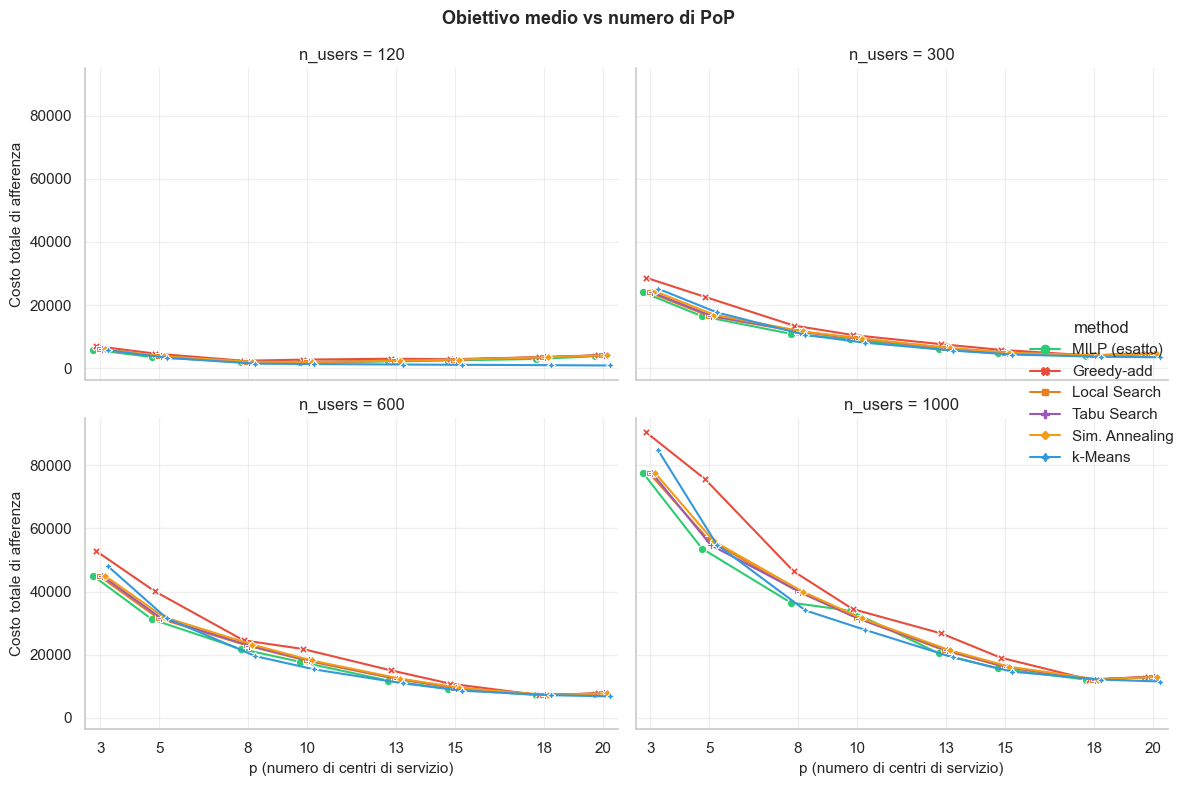

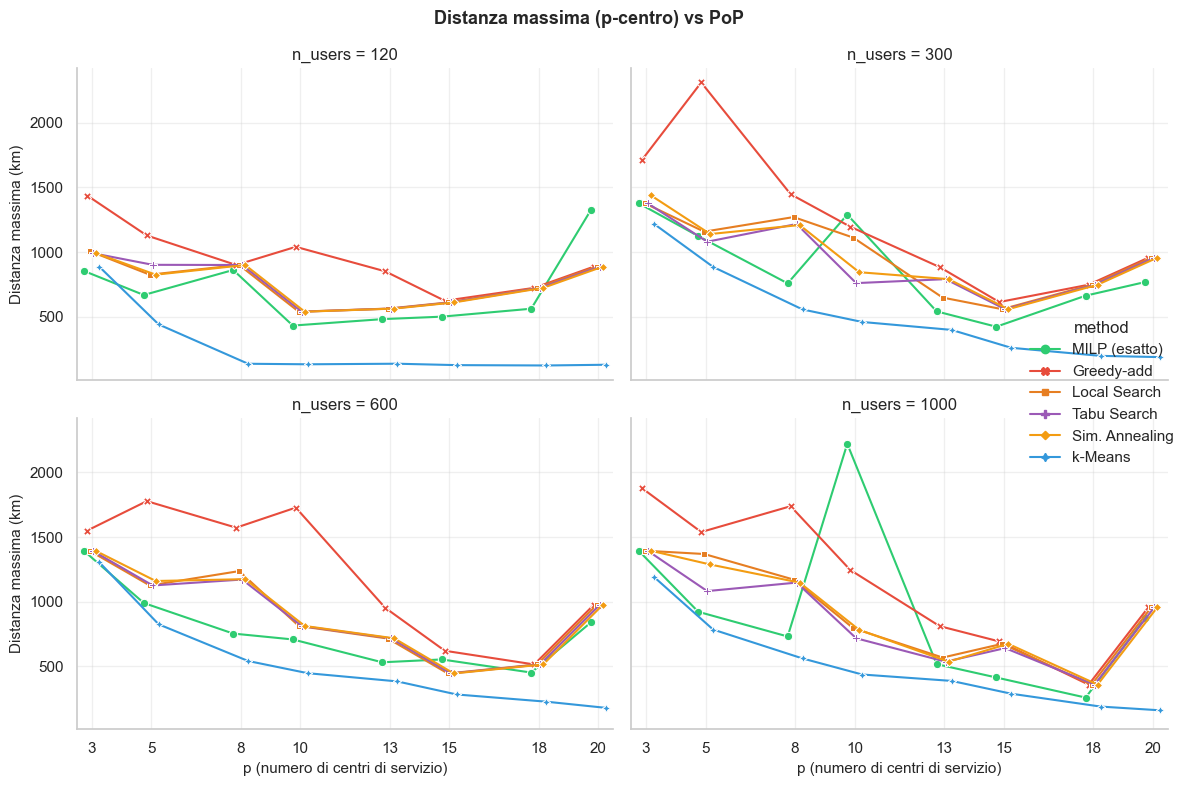

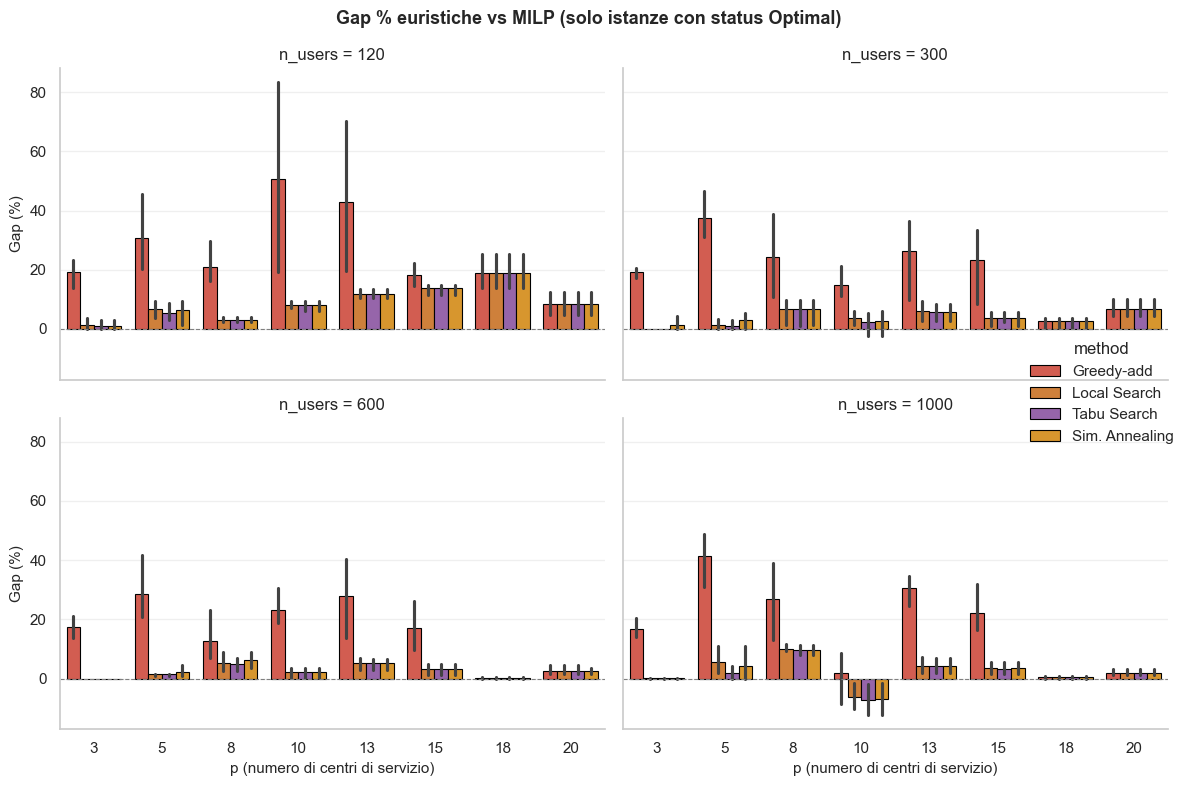

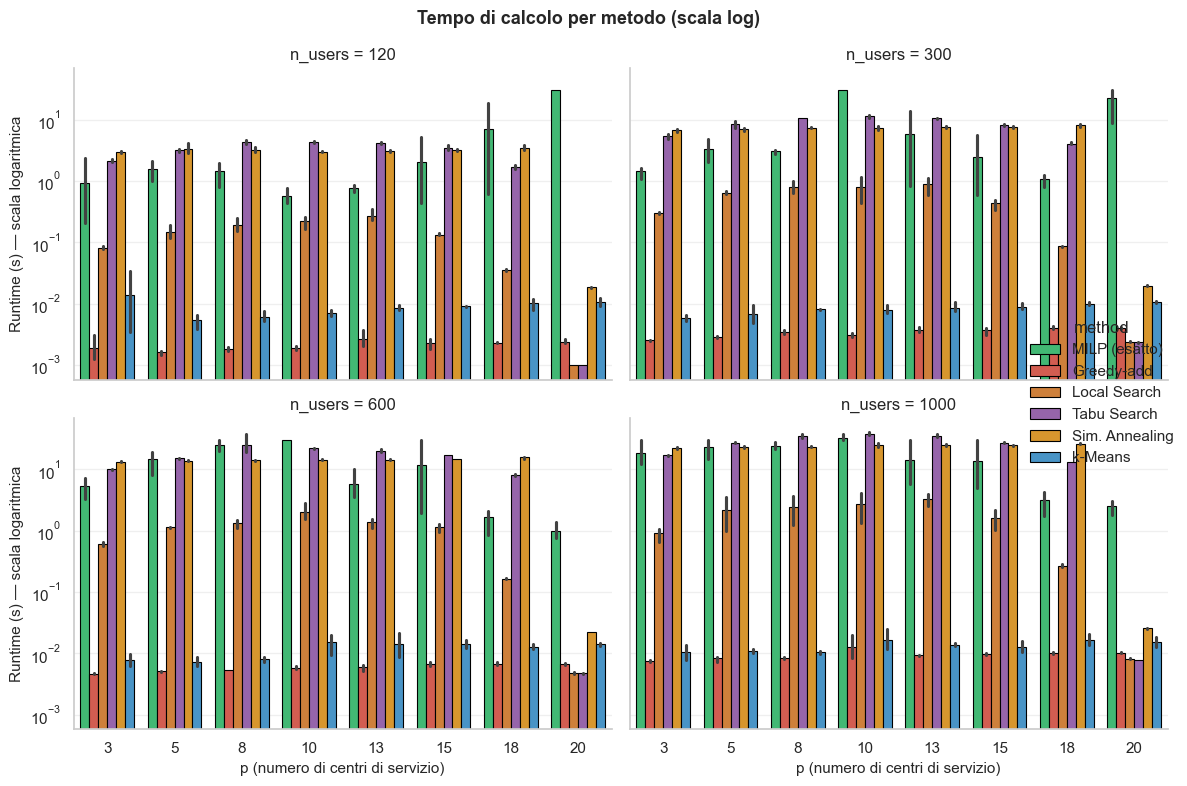

In [11]:
# ── Creazione cartelle di output ───────────────────────────────────
results_dir = Path('results')
plots_dir = results_dir / 'plots'
results_dir.mkdir(exist_ok=True, parents=True)
plots_dir.mkdir(exist_ok=True, parents=True)

# Salvataggio CSV
results_df.to_csv(results_dir / 'results.csv', index=False)
print(f"Risultati salvati in {results_dir / 'results.csv'}")

# ── Palette e configurazione per 6 metodi ─────────────────────────
METHOD_STYLE = {
    'milp':          {'color': '#2ecc71', 'label': 'MILP (esatto)'},
    'greedy':        {'color': '#e74c3c', 'label': 'Greedy-add'},
    'local_search':  {'color': '#e67e22', 'label': 'Local Search'},
    'tabu_search':   {'color': '#9b59b6', 'label': 'Tabu Search'},
    'sim_annealing': {'color': '#f39c12', 'label': 'Sim. Annealing'},
    'kmeans':        {'color': '#3498db', 'label': 'k-Means'},
}
palette = {m: s['color'] for m, s in METHOD_STYLE.items()}
method_labels = {m: s['label'] for m, s in METHOD_STYLE.items()}

# Piccolo offset orizzontale per distinguere curve sovrapposte (es. Local/Tabu/SA)
method_order = list(METHOD_STYLE.keys())
dodge = 0.10
offsets = {m: (i - (len(method_order) - 1) / 2) * dodge for i, m in enumerate(method_order)}
plot_df = results_df.copy()
plot_df['p_plot'] = (plot_df['p'] + plot_df['method'].map(offsets)).round(3)
p_ticks = sorted(plot_df['p'].unique())

# ── Facet per n_users ───────────────────────────────────────────
n_users_vals = sorted(results_df['n_users'].unique())
col_wrap = 2 if len(n_users_vals) > 2 else None

# ── Grafico 1: Obiettivo medio vs p (facet) ─────────────────────
g = sns.relplot(
    data=plot_df, x='p_plot', y='objective', hue='method',
    hue_order=method_order, style='method', style_order=method_order,
    markers=True, dashes=False, palette=palette,
    errorbar=None, kind='line', col='n_users', col_wrap=col_wrap,
    height=4, aspect=1.3,
)
for ax in g.axes.flat:
    ax.set_title(f"n_users = {ax.get_title().split(' = ')[-1]}")
    ax.set_xlabel('p (numero di centri di servizio)', fontsize=11)
    ax.set_ylabel('Costo totale di afferenza', fontsize=11)
    ax.set_xticks(p_ticks)
    ax.set_xticklabels([str(p) for p in p_ticks])
    ax.set_xlim(min(p_ticks) - 0.5, max(p_ticks) + 0.5)
    ax.grid(True, alpha=0.3)
if g._legend is None:
    g.add_legend(title='Metodo')
if g._legend:
    for t in g._legend.texts:
        t.set_text(method_labels.get(t.get_text(), t.get_text()))

g.fig.suptitle('Obiettivo medio vs numero di PoP', fontweight='bold', fontsize=13)
g.fig.tight_layout()
plt.savefig(plots_dir / 'objective_vs_p_facet.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Grafico 2: Distanza massima media vs p (facet) ───────────────
g = sns.relplot(
    data=plot_df, x='p_plot', y='max_distance_km', hue='method',
    hue_order=method_order, style='method', style_order=method_order,
    markers=True, dashes=False, palette=palette,
    errorbar=None, kind='line', col='n_users', col_wrap=col_wrap,
    height=4, aspect=1.3,
)
for ax in g.axes.flat:
    ax.set_title(f"n_users = {ax.get_title().split(' = ')[-1]}")
    ax.set_xlabel('p (numero di centri di servizio)', fontsize=11)
    ax.set_ylabel('Distanza massima (km)', fontsize=11)
    ax.set_xticks(p_ticks)
    ax.set_xticklabels([str(p) for p in p_ticks])
    ax.set_xlim(min(p_ticks) - 0.5, max(p_ticks) + 0.5)
    ax.grid(True, alpha=0.3)
if g._legend is None:
    g.add_legend(title='Metodo')
if g._legend:
    for t in g._legend.texts:
        t.set_text(method_labels.get(t.get_text(), t.get_text()))

g.fig.suptitle('Distanza massima (p-centro) vs PoP', fontweight='bold', fontsize=13)
g.fig.tight_layout()
plt.savefig(plots_dir / 'max_distance_vs_p_facet.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Grafico 3: Gap % euristiche vs MILP (facet) ─────────────────
milp_df = results_df[
    (results_df['method'] == 'milp') & (results_df['status'] == 'Optimal')
][['n_users', 'p', 'seed', 'objective']].rename(
    columns={'objective': 'obj_milp'}
)
heuristic_methods = ['greedy', 'local_search', 'tabu_search', 'sim_annealing']
gap_rows = []
for m in heuristic_methods:
    m_df = results_df[
        (results_df['method'] == m) & np.isfinite(results_df['objective'])
    ][['n_users', 'p', 'seed', 'objective']].rename(
        columns={'objective': 'obj_eur'}
    )
    merged = milp_df.merge(m_df, on=['n_users', 'p', 'seed'])
    merged['gap_pct'] = (merged['obj_eur'] - merged['obj_milp']) / merged['obj_milp'] * 100
    merged['method'] = m
    gap_rows.append(merged)
gap_df = pd.concat(gap_rows, ignore_index=True)

if gap_df.empty:
    print('Nessun confronto gap disponibile: MILP non ottimo nelle istanze considerate.')
else:
    gap_palette = {m: palette[m] for m in heuristic_methods}
    g = sns.catplot(
        data=gap_df, x='p', y='gap_pct', hue='method',
        palette=gap_palette, kind='bar', col='n_users', col_wrap=col_wrap,
        height=4, aspect=1.3, edgecolor='black', linewidth=0.8,
    )
    for ax in g.axes.flat:
        ax.set_xlabel('p (numero di centri di servizio)', fontsize=11)
        ax.set_ylabel('Gap (%)', fontsize=11)
        ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
        ax.grid(True, alpha=0.3, axis='y')
    if g._legend is None:
        g.add_legend(title='Metodo')
    if g._legend:
        for t in g._legend.texts:
            t.set_text(method_labels.get(t.get_text(), t.get_text()))

    g.fig.suptitle('Gap % euristiche vs MILP (solo istanze con status Optimal)', fontweight='bold', fontsize=13)
    g.fig.tight_layout()
    plt.savefig(plots_dir / 'gap_vs_milp_facet.png', dpi=200, bbox_inches='tight')
    plt.show()

# ── Grafico 4: Confronto runtime (scala log, facet) ─────────────
g = sns.catplot(
    data=results_df, x='p', y='runtime', hue='method',
    palette=palette, kind='bar', col='n_users', col_wrap=col_wrap,
    height=4, aspect=1.3, edgecolor='black', linewidth=0.8,
)
for ax in g.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel('p (numero di centri di servizio)', fontsize=11)
    ax.set_ylabel('Runtime (s) — scala logaritmica', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
if g._legend is None:
    g.add_legend(title='Metodo')
if g._legend:
    for t in g._legend.texts:
        t.set_text(method_labels.get(t.get_text(), t.get_text()))

g.fig.suptitle('Tempo di calcolo per metodo (scala log)', fontweight='bold', fontsize=13)
g.fig.tight_layout()
plt.savefig(plots_dir / 'runtime_facet.png', dpi=200, bbox_inches='tight')
plt.show()


### Tabelle riepilogative dei risultati numerici per ciascun valore di *p*

Per ogni valore di *p* si riporta una tabella con media e intervallo di confidenza al 95 % (distribuzione *t* di Student), insieme allo stato dei solver e a un flag di ottimalità MILP. Il **miglior risultato** per ciascuna metrica è evidenziato in verde.

In [12]:
# ── Tabelle numeriche per ciascun valore di p (con IC 95 %) ───────
from scipy import stats as _stats

_metrics = ['objective', 'max_distance_km', 'runtime']
_metric_labels = {
    'objective': 'Costo afferenza',
    'max_distance_km': 'Dist. max (km)',
    'runtime': 'Runtime (s)',
}

for p_val in sorted(results_df['p'].unique()):
    _table_rows = []
    for m in METHOD_STYLE:
        sub = results_df[(results_df['method'] == m) & (results_df['p'] == p_val)]
        status_counts = sub['status'].dropna().astype(str).value_counts()
        status_text = ', '.join(f'{k}:{v}' for k, v in status_counts.items()) if not status_counts.empty else 'n/a'
        if m == 'milp':
            n_opt = int((sub['status'] == 'Optimal').sum())
            n_tot = int(len(sub))
            if n_tot == 0:
                milp_opt_flag = 'n/a'
            elif n_opt == n_tot:
                milp_opt_flag = f'Si ({n_opt}/{n_tot})'
            elif n_opt > 0:
                milp_opt_flag = f'Parziale ({n_opt}/{n_tot})'
            else:
                milp_opt_flag = f'No (0/{n_tot})'
        else:
            milp_opt_flag = '—'
        row = {
            'Metodo': METHOD_STYLE[m]['label'],
            'Stato': status_text,
            'MILP ottimo': milp_opt_flag,
        }
        for metric in _metrics:
            vals = sub[metric].dropna()
            n = len(vals)
            mu = vals.mean()
            if n > 1:
                sem = vals.std(ddof=1) / np.sqrt(n)
                t_crit = _stats.t.ppf(0.975, df=n - 1)
                ci = t_crit * sem
            else:
                ci = 0.0
            row[_metric_labels[metric]] = mu
            row[f'±95% CI ({_metric_labels[metric]})'] = ci
        _table_rows.append(row)

    df_p = pd.DataFrame(_table_rows)

    # Evidenzia migliore e secondo per ogni metrica — colori per dark theme
    def _highlight_best(s):
        """Evidenzia il valore minimo e il secondo per colonna."""
        finite_vals = [v for v in s if np.isfinite(v)]
        if not finite_vals:
            return [''] * len(s)
        vals = sorted(set(finite_vals))
        best = vals[0]
        second = vals[1] if len(vals) > 1 else None
        styles = []
        for v in s:
            if not np.isfinite(v):
                styles.append('')
            elif np.isclose(v, best):
                styles.append('background-color: #1a5e2a !important; color: #8fffb0 !important; font-weight: bold')
            elif second is not None and np.isclose(v, second):
                styles.append('background-color: #7a6a00 !important; color: #fff3b0 !important; font-weight: bold')
            else:
                styles.append('')
        return styles
    value_cols = list(_metric_labels.values())
    styled = (df_p.style
              .set_table_styles([
                  {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px'),
                                                     ('margin-bottom', '8px'), ('color', '#e0e0e0')]},
                  {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#e0e0e0'),
                                                ('font-size', '11px')]},
                  {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'center'),
                                                ('color', '#d0d0d0'), ('background-color', '#1e1e1e')]},
              ])
              .apply(_highlight_best, subset=value_cols)
              .format({
                  'Costo afferenza': '{:.1f}',
                  '±95% CI (Costo afferenza)': '±{:.1f}',
                  'Dist. max (km)': '{:.1f}',
                  '±95% CI (Dist. max (km))': '±{:.1f}',
                  'Runtime (s)': '{:.4f}',
                  '±95% CI (Runtime (s))': '±{:.4f}',
              })
              .set_caption(f'Risultati per p = {p_val} — media ± IC 95 %')
              .hide(axis='index'))
    display(styled)
    print()  # spacer between tables

Metodo,Stato,MILP ottimo,Costo afferenza,±95% CI (Costo afferenza),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (esatto),Optimal:12,Si (12/12),38151.7,±17711.3,1254.5,±153.9,6.5538,±5.4569
Greedy-add,greedy:12,—,44777.5,±20592.9,1644.4,±285.3,0.0041,±0.0015
Local Search,local_search:12,—,38183.6,±17708.2,1292.7,±135.0,0.4709,±0.2154
Tabu Search,tabu_search:12,—,38180.3,±17710.8,1288.9,±134.7,8.5892,±3.7063
Sim. Annealing,simulated_annealing:12,—,38266.8,±17682.6,1304.4,±143.4,11.3298,±4.8316
k-Means,kmeans:12,—,41009.5,±19604.4,1152.8,±117.9,0.0096,±0.0052


Metodo,Stato,MILP ottimo,Costo afferenza,±95% CI (Costo afferenza),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (esatto),Optimal:12,Si (12/12),26192.2,±12366.4,926.2,±123.8,10.5626,±6.2967
Greedy-add,greedy:12,—,35720.7,±17452.2,1689.2,±337.9,0.0045,±0.0017
Local Search,local_search:12,—,27162.8,±13102.7,1119.5,±167.2,1.0195,±0.6100
Tabu Search,tabu_search:12,—,26656.5,±12606.4,1047.5,±109.9,13.4653,±5.9182
Sim. Annealing,simulated_annealing:12,—,27129.9,±12929.7,1103.3,±170.3,11.6690,±4.9029
k-Means,kmeans:12,—,26842.0,±12669.1,734.0,±121.3,0.0075,±0.0016


Metodo,Stato,MILP ottimo,Costo afferenza,±95% CI (Costo afferenza),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (esatto),Optimal:12,Si (12/12),17782.3,±8575.4,776.3,±109.3,13.3012,±7.7836
Greedy-add,greedy:12,—,21688.0,±10947.9,1414.7,±270.7,0.0048,±0.0016
Local Search,local_search:12,—,19182.4,±9450.9,1144.8,±241.8,1.1913,±0.6473
Tabu Search,tabu_search:12,—,19109.6,±9396.3,1109.2,±209.4,18.8190,±8.4658
Sim. Annealing,simulated_annealing:12,—,19183.7,±9407.3,1107.9,±238.2,11.9532,±5.0783
k-Means,kmeans:12,—,16360.5,±7989.3,449.1,±123.7,0.0081,±0.0011


Metodo,Stato,MILP ottimo,Costo afferenza,±95% CI (Costo afferenza),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (esatto),Optimal:12,Si (12/12),15652.7,±7969.4,1162.8,±559.3,23.3586,±8.8389
Greedy-add,greedy:12,—,17350.5,±7965.9,1302.7,±259.6,0.0059,±0.0033
Local Search,local_search:12,—,15321.8,±7360.9,814.9,±199.3,1.4233,±0.7740
Tabu Search,tabu_search:12,—,15203.6,±7288.8,707.4,±102.8,18.9245,±8.4924
Sim. Annealing,simulated_annealing:12,—,15230.9,±7308.5,744.7,±106.1,12.3342,±5.4471
k-Means,kmeans:12,—,13136.6,±6553.1,369.3,±92.3,0.0117,±0.0038


Metodo,Stato,MILP ottimo,Costo afferenza,±95% CI (Costo afferenza),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (esatto),Optimal:12,Si (12/12),10082.8,±4589.2,518.1,±25.9,6.5654,±5.3548
Greedy-add,greedy:12,—,13060.5,±5978.6,875.0,±117.5,0.0054,±0.0017
Local Search,local_search:12,—,10613.0,±4759.4,623.7,±68.9,1.4385,±0.7608
Tabu Search,tabu_search:12,—,10599.0,±4754.0,651.9,±127.8,17.5145,±7.7665
Sim. Annealing,simulated_annealing:12,—,10599.0,±4754.0,651.9,±127.8,12.4325,±5.4584
k-Means,kmeans:12,—,9173.6,±4446.1,326.9,±74.8,0.0112,±0.0026


Metodo,Stato,MILP ottimo,Costo afferenza,±95% CI (Costo afferenza),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (esatto),Optimal:12,Si (12/12),7975.2,±3362.0,473.0,±102.3,7.4537,±6.7854
Greedy-add,greedy:12,—,9606.5,±4097.4,637.9,±55.1,0.0056,±0.0019
Local Search,local_search:12,—,8307.8,±3426.9,572.3,±123.9,0.8269,±0.4130
Tabu Search,tabu_search:12,—,8291.0,±3410.2,564.0,±126.3,13.9065,±5.9655
Sim. Annealing,simulated_annealing:12,—,8307.8,±3426.9,572.3,±123.9,12.4636,±5.3617
k-Means,kmeans:12,—,7120.4,±3367.3,239.5,±44.8,0.0112,±0.0018


Metodo,Stato,MILP ottimo,Costo afferenza,±95% CI (Costo afferenza),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (esatto),Optimal:12,Si (12/12),6521.7,±2369.9,484.1,±206.8,3.2463,±3.1619
Greedy-add,greedy:12,—,6696.9,±2282.6,586.3,±216.8,0.0058,±0.0020
Local Search,local_search:12,—,6696.9,±2282.6,586.3,±216.8,0.1386,±0.0586
Tabu Search,tabu_search:12,—,6696.9,±2282.6,586.3,±216.8,6.7348,±2.8644
Sim. Annealing,simulated_annealing:12,—,6696.9,±2282.6,586.3,±216.8,13.3281,±5.6918
k-Means,kmeans:12,—,5938.2,±2776.7,184.5,±30.4,0.0123,±0.0022


Metodo,Stato,MILP ottimo,Costo afferenza,±95% CI (Costo afferenza),Dist. max (km),±95% CI (Dist. max (km)),Runtime (s),±95% CI (Runtime (s))
MILP (esatto),Optimal:12,Si (12/12),7077.8,±2363.8,952.0,±202.9,14.0585,±8.9742
Greedy-add,greedy:12,—,7337.7,±2352.0,944.0,±137.4,0.0058,±0.0020
Local Search,local_search:12,—,7337.7,±2352.0,944.0,±137.4,0.0041,±0.0018
Tabu Search,tabu_search:12,—,7337.7,±2352.0,944.0,±137.4,0.0040,±0.0017
Sim. Annealing,simulated_annealing:12,—,7337.7,±2352.0,944.0,±137.4,0.0214,±0.0018
k-Means,kmeans:12,—,5631.9,±2641.9,164.3,±20.2,0.0126,±0.0016


In [13]:
# ── Ranking complessivo per obiettivo medio ────────────────────────
valid_results = results_df[np.isfinite(results_df['objective'])].copy()
all_mean = valid_results.groupby('method').agg(
    obj_mean=('objective', 'mean'),
    dist_mean=('max_distance_km', 'mean'),
    time_mean=('runtime', 'mean'),
)
milp_opt = valid_results[(valid_results['method'] == 'milp') & (valid_results['status'] == 'Optimal')]
milp_avg_obj = milp_opt['objective'].mean() if not milp_opt.empty else float('nan')

ranking = all_mean['obj_mean'].sort_values()
_rank_rows = []
for rank, (m, val) in enumerate(ranking.items(), 1):
    if m == 'milp':
        gap_display = '—'
    elif np.isfinite(milp_avg_obj) and milp_avg_obj > 0:
        gap_display = f'{(val - milp_avg_obj)/milp_avg_obj*100:.2f}%'
    else:
        gap_display = 'n/a (MILP non ottimo)'
    _rank_rows.append({
        '#': rank,
        'Metodo': METHOD_STYLE[m]['label'],
        'Obj. medio': f'{val:.1f}',
        'Gap medio vs MILP': gap_display,
    })

_df_rank = pd.DataFrame(_rank_rows)

styled = (_df_rank.style
          .hide(axis='index')
          .set_caption('Ranking complessivo per obiettivo medio (tutti i p e seed)')
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px'),
                                                 ('margin-bottom', '8px'), ('color', '#e0e0e0')]},
              {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#e0e0e0')]},
              {'selector': 'td', 'props': [('text-align', 'center'), ('color', '#d0d0d0'),
                                            ('background-color', '#1e1e1e')]},
          ]))
display(styled)

#,Metodo,Obj. medio,Gap medio vs MILP
1,k-Means,15651.6,-3.26%
2,MILP (esatto),16179.5,—
3,Tabu Search,16509.3,2.04%
4,Sim. Annealing,16594.1,2.56%
5,Local Search,16600.7,2.60%
6,Greedy-add,19529.8,20.71%


## 9 • Visualizzazione geospaziale del clustering

Per un'istanza rappresentativa (`seed=0`, `p=5`) si visualizzano su **mappa interattiva** (Folium) i risultati di tutti e sei i metodi risolutivi. Ogni utente è collegato al proprio centro con un colore che identifica il cluster, rendendo immediatamente comprensibile la struttura spaziale della soluzione e le differenze tra i diversi approcci.

- **MILP** — soluzione esatta (solutore CBC);
- **Greedy-add** — euristica costruttiva;
- **Local Search** — euristica migliorativa (Teitz & Bart);
- **Tabu Search** — metaeuristica con lista tabù;
- **Simulated Annealing** — metaeuristica con accettazione probabilistica;
- **k-Means** — baseline con centroidi *immaginari* (non vincolati ai candidati PoP).

In [24]:
# ── Mappe geospaziali per TUTTI i metodi — seed=0, p=5 ────────────

# Colori cluster
CLUSTER_COLORS = [
    '#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12',
    '#1abc9c', '#e67e22', '#34495e', '#e91e63', '#00bcd4',
]

def make_cluster_map(coords, assign, open_hubs, title='Clustering',
                     hub_coords=None, hub_labels=None):
    """Crea una mappa Folium con cluster colorati e linee di assegnamento."""
    center_lat = float(np.mean(coords[:, 0]))
    center_lon = float(np.mean(coords[:, 1]))
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles='CartoDB positron')

    _hub_coords = hub_coords if hub_coords is not None else pop_coords
    _hub_labels = hub_labels

    hub_color = {h: CLUSTER_COLORS[idx % len(CLUSTER_COLORS)] for idx, h in enumerate(open_hubs)}

    for h in open_hubs:
        label = _hub_labels[h] if _hub_labels is not None else POP_CANDIDATES[h]['name']
        folium.Marker(
            location=[float(_hub_coords[h, 0]), float(_hub_coords[h, 1])],
            popup=label,
            icon=folium.Icon(color='white', icon_color=hub_color[h], icon='server', prefix='fa'),
        ).add_to(m)

    for i in range(len(coords)):
        hub = int(assign[i])
        color = hub_color.get(hub, 'gray')
        folium.CircleMarker(
            location=[float(coords[i, 0]), float(coords[i, 1])],
            radius=4, color=color, fill=True, fill_opacity=0.7, weight=1,
        ).add_to(m)
        folium.PolyLine(
            locations=[
                [float(coords[i, 0]), float(coords[i, 1])],
                [float(_hub_coords[hub, 0]), float(_hub_coords[hub, 1])],
            ],
            color=color, weight=1.5, opacity=0.4,
        ).add_to(m)

    title_html = f'<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);z-index:9999;background:white;padding:8px 16px;border-radius:8px;box-shadow:0 2px 6px rgba(0,0,0,.3);font:bold 14px sans-serif;">{title}</div>'
    m.get_root().html.add_child(folium.Element(title_html))
    return m


# ── Preparazione istanza seed=0, p=5 ──────────────────────────────
_seed, _p = 0, 5
_coords, _demands = sample_users(120, _seed)
_dist_km = haversine_matrix(_coords, pop_coords)
_eff = effective_cost_per_km()
_dist_cost = _dist_km * _eff
_caps = build_capacities(_demands, _p, _seed)

# ── Soluzione MILP ──
_milp = solve_pmedian_pulp(_dist_cost, _demands, _p, capacities=_caps)
map_milp = make_cluster_map(_coords, _milp['assign'], _milp['open'],
                            title='Clustering MILP — p=5, seed=0')

# ── Soluzione Greedy ──
_greedy = greedy_solution(_dist_cost, _demands, _p, capacities=_caps)
map_greedy = make_cluster_map(_coords, _greedy['assign'], _greedy['open'],
                              title='Clustering Greedy — p=5, seed=0')

# ── Soluzione Local Search ──
_ls = local_search_swap(_dist_cost, _demands, _p, capacities=_caps,
                        initial_open=list(_greedy['open']))
map_ls = make_cluster_map(_coords, _ls['assign'], _ls['open'],
                          title='Clustering Local Search — p=5, seed=0')

# ── Soluzione Tabu Search ──
_ts = tabu_search(_dist_cost, _demands, _p, capacities=_caps,
                  initial_open=list(_greedy['open']))
map_ts = make_cluster_map(_coords, _ts['assign'], _ts['open'],
                          title='Clustering Tabu Search — p=5, seed=0')

# ── Soluzione Simulated Annealing ──
_sa = simulated_annealing(_dist_cost, _demands, _p, capacities=_caps,
                          initial_open=list(_greedy['open']), seed=_seed)
map_sa = make_cluster_map(_coords, _sa['assign'], _sa['open'],
                          title='Clustering Sim. Annealing — p=5, seed=0')

# ── Soluzione k-Means (centroidi immaginari) ──
_kmeans = kmeans_baseline(_coords, _demands, _p, _seed)
_km_centroids = _kmeans['centroids']
_km_labels = _kmeans['assign']
_km_hub_labels = {i: f'Centroide {i+1}' for i in range(_p)}
map_kmeans = make_cluster_map(
    _coords, _km_labels, list(range(_p)),
    title='Clustering k-Means — p=5, seed=0',
    hub_coords=_km_centroids,
    hub_labels=_km_hub_labels,
)

print("▶ Mappa MILP (soluzione esatta):")
map_milp

▶ Mappa MILP (soluzione esatta):


In [21]:
print("▶ Mappa Greedy-add:")
map_greedy

▶ Mappa Greedy-add:


In [23]:
print("▶ Mappa k-Means (centroidi immaginari):")
map_kmeans

▶ Mappa k-Means (centroidi immaginari):


## 10 • Heatmap delle distanze

La **heatmap** mostra la matrice delle distanze (km) tra tutti i nodi di domanda e i candidati centri di servizio (PoP), evidenziando le zone a distanza alta/bassa. Non rappresenta una soluzione specifica, ma la struttura del problema: permette di individuare quali centri sono naturalmente più vicini a determinati gruppi di utenti.

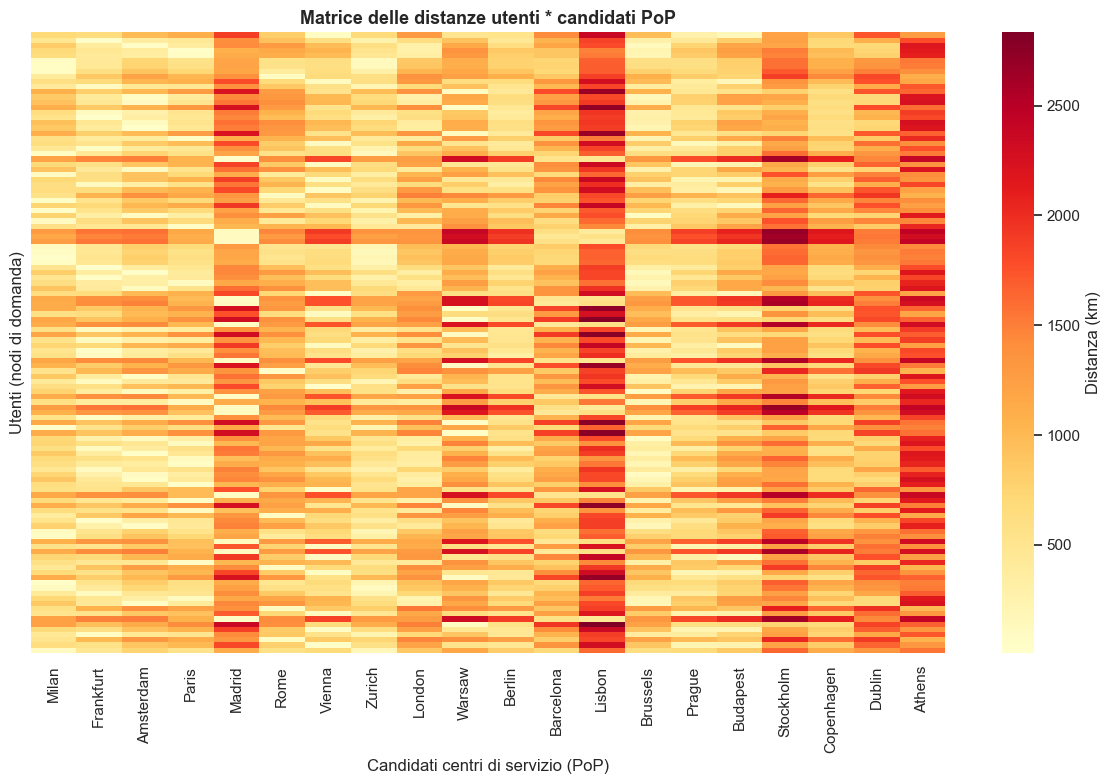

In [17]:
# ── Heatmap distanze utenti * candidati PoP ───────────────────────
pop_names = [c['name'] for c in POP_CANDIDATES]
heatmap_data = pd.DataFrame(_dist_km, columns=pop_names)
heatmap_data.index.name = 'Utente'

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Distanza (km)'},
    xticklabels=True,
    yticklabels=False,
)
ax.set_title('Matrice delle distanze utenti * candidati PoP', fontweight='bold', fontsize=13)
ax.set_xlabel('Candidati centri di servizio (PoP)')
ax.set_ylabel('Utenti (nodi di domanda)')
plt.tight_layout()
plt.savefig(plots_dir / 'heatmap_distanze.png', dpi=200, bbox_inches='tight')
plt.show()

## 11 • Risoluzione con GUROBI

In questa sezione il modello MILP della p-mediana capacitata viene risolto con **GUROBI** tramite `gurobipy`.

La configurazione della licenza usa variabili d'ambiente lette da file `.env`:
- `GUROBI_WLSACCESSID`
- `GUROBI_WLSSECRET`
- `GUROBI_LICENSEID`

L'obiettivo è un confronto operativo con CBC sulla stessa istanza:
- confronto di **valore obiettivo** (coerenza tra solver esatti);
- confronto dei **tempi di calcolo** (speed-up);
- verifica dello **stato di soluzione** e del **MIP gap**.

La formulazione resta invariata (stesse variabili e stessi vincoli): cambia solo il motore di ottimizzazione.



In [ ]:
# ── Risoluzione MILP con GUROBI (gurobipy + .env) ──────────────────
import os
import time as _time
from pathlib import Path as _Path

from dotenv import load_dotenv
import gurobipy as gp
from gurobipy import GRB

load_dotenv(_Path('.env'))

_wls_access_id = os.getenv('GUROBI_WLSACCESSID', '').strip()
_wls_secret = os.getenv('GUROBI_WLSSECRET', '').strip()
_license_id_raw = os.getenv('GUROBI_LICENSEID', '').strip()

_missing_env = [
    name for name, value in {
        'GUROBI_WLSACCESSID': _wls_access_id,
        'GUROBI_WLSSECRET': _wls_secret,
        'GUROBI_LICENSEID': _license_id_raw,
    }.items()
    if not value
]
if _missing_env:
    raise RuntimeError(
        'Variabili GUROBI mancanti nel file .env: ' + ', '.join(_missing_env)
    )

try:
    _license_id = int(_license_id_raw)
except ValueError as e:
    raise RuntimeError('GUROBI_LICENSEID deve essere un intero') from e

_wls_params = {
    'WLSACCESSID': _wls_access_id,
    'WLSSECRET': _wls_secret,
    'LICENSEID': _license_id,
}

try:
    _gurobi_env = gp.Env(params=_wls_params)
except Exception as e:
    raise RuntimeError('Impossibile inizializzare GUROBI WLS con le credenziali fornite') from e

_test = gp.Model('_test', env=_gurobi_env)
_test.Params.OutputFlag = 0
_test.addVar(vtype=GRB.BINARY, name='_t')
_test.setObjective(0.0, GRB.MINIMIZE)
_test.optimize()
if _test.Status != GRB.OPTIMAL:
    raise RuntimeError(f'test iniziale GUROBI fallito: status={_test.Status}')


def solve_pmedian_gurobi(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
) -> dict:
    """Risolve il Capacitated p-Median con GUROBI via gurobipy.

    Formulazione identica a quella usata con PuLP/CPLEX:
        min  Σ_i Σ_j  d_i * c_ij * x_ij
        s.t. Σ_j y_j = p
             Σ_j x_ij = 1               ∀ i  (assegnamento unico)
             x_ij ≤ y_j                  ∀ i,j
             Σ_i d_i * x_ij ≤ Q_j * y_j ∀ j  (capacità)
             x_ij ∈ {0,1}, y_j ∈ {0,1}
    """
    n_users, n_candidates = dist_cost.shape
    mdl = gp.Model('capacitated_p_median', env=_gurobi_env)
    mdl.Params.OutputFlag = 0

    # ── Variabili ──
    x = mdl.addVars(n_users, n_candidates, vtype=GRB.BINARY, name='x')
    y = mdl.addVars(n_candidates, vtype=GRB.BINARY, name='y')

    # ── Funzione obiettivo ──
    mdl.setObjective(
        gp.quicksum(
            float(demands[i]) * float(dist_cost[i, j]) * x[i, j]
            for i in range(n_users)
            for j in range(n_candidates)
        ),
        GRB.MINIMIZE,
    )

    # ── Vincoli ──
    mdl.addConstr(gp.quicksum(y[j] for j in range(n_candidates)) == p, name='num_hubs')
    for i in range(n_users):
        mdl.addConstr(gp.quicksum(x[i, j] for j in range(n_candidates)) == 1, name=f'assign_{i}')
    for i in range(n_users):
        for j in range(n_candidates):
            mdl.addConstr(x[i, j] <= y[j], name=f'link_{i}_{j}')
    for j in range(n_candidates):
        mdl.addConstr(
            gp.quicksum(float(demands[i]) * x[i, j] for i in range(n_users))
            <= float(capacities[j]) * y[j],
            name=f'cap_{j}',
        )

    # ── Risoluzione ──
    t0 = _time.perf_counter()
    mdl.optimize()
    runtime = _time.perf_counter() - t0

    if mdl.SolCount == 0:
        raise RuntimeError(f'solve_pmedian_gurobi: nessuna soluzione, status={mdl.Status}')

    status = 'gurobi_optimal' if mdl.Status == GRB.OPTIMAL else 'gurobi_feasible'
    open_hubs = [j for j in range(n_candidates) if y[j].X > 0.5]
    assign = np.array([
        int(np.argmax([x[i, j].X for j in range(n_candidates)]))
        for i in range(n_users)
    ], dtype=int)

    return {
        'status': status,
        'objective': float(mdl.ObjVal),
        'open': open_hubs,
        'assign': assign,
        'runtime': runtime,
        'feasible': True,
        'gap': float(mdl.MIPGap) if mdl.IsMIP else None,
        'solve_details': f'status={mdl.Status}',
    }


# ── Esecuzione confronto GUROBI vs CBC ─────────────────────────────
_n_cand = len(POP_CANDIDATES)
_n_gurobi = CONFIG['n_users'][0]

print('=' * 65)
print('  CONFRONTO  GUROBI  vs  CBC (PuLP)  —  p-mediana capacitata')
print('=' * 65)
print(f'  Istanza: {_n_gurobi} utenti, {_n_cand} candidati')
print()

_seed = CONFIG['seeds'][0]
_coords, _demands = sample_users(_n_gurobi, _seed)
_dist_km = haversine_matrix(_coords, pop_coords)
_dist_cost = _dist_km * effective_cost_per_km()

gurobi_results = {}
cbc_sub_results = {}
for p_val in CONFIG['p_values']:
    _caps = build_capacities(_demands, p_val, _seed)
    print(f'▸ p = {p_val}', flush=True)

    # ── GUROBI sull'istanza ──
    res_grb = solve_pmedian_gurobi(_dist_cost, _demands, p_val, _caps)
    gurobi_results[p_val] = res_grb
    print(f"  GUROBI: obj = {res_grb['objective']:.1f}  "
          f"t = {res_grb['runtime']:.2f}s  ({res_grb['status']})")

    # ── CBC (PuLP) sulla stessa istanza ──
    res_cbc = solve_pmedian_pulp(_dist_cost, _demands, p_val, _caps)
    cbc_sub_results[p_val] = res_cbc
    print(f"  CBC:    obj = {res_cbc['objective']:.1f}  "
          f"t = {res_cbc['runtime']:.2f}s")

# ── Tabella comparativa ──
rows_cmp = []
for p_val in CONFIG['p_values']:
    grb = gurobi_results[p_val]
    cbc = cbc_sub_results[p_val]
    cbc_obj = cbc['objective']
    if grb['runtime'] <= 0:
        raise RuntimeError('Runtime GUROBI non positivo: impossibile calcolare speed-up')
    rows_cmp.append({
        'p': p_val,
        'Obj CBC': cbc_obj,
        'Obj GUROBI': grb['objective'],
        'Gap Obj (%)': abs(grb['objective'] - cbc_obj) / cbc_obj * 100 if cbc_obj else 0,
        'T. CBC (s)': cbc['runtime'],
        'T. GUROBI (s)': grb['runtime'],
        'Speed-up': cbc['runtime'] / grb['runtime'],
    })

if rows_cmp:
    df_cmp = pd.DataFrame(rows_cmp).set_index('p')
    speedup_series = df_cmp['Speed-up']
    speedup_min = 0.5
    speedup_cap = float(speedup_series.quantile(0.75))
    speedup_cap = max(min(speedup_cap, 6.0), 2.0)
    speedup_gmap = speedup_series.clip(lower=speedup_min, upper=speedup_cap)

    display(df_cmp.style
            .format({'Obj CBC': '{:.1f}', 'Obj GUROBI': '{:.1f}',
                     'Gap Obj (%)': '{:.2f}', 'T. CBC (s)': '{:.3f}',
                     'T. GUROBI (s)': '{:.3f}', 'Speed-up': '{:.1f}×'})
            .background_gradient(subset=['Speed-up'], cmap='Greens',
                                 vmin=speedup_min, vmax=speedup_cap,
                                 gmap=speedup_gmap,
                                 low=0.2, high=0.95)
            .set_caption(f'Confronto GUROBI vs CBC — istanza {_n_gurobi} utenti')
            .set_table_styles([
                {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px'),
                                                   ('margin-bottom', '8px'), ('color', '#e0e0e0')]},
                {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#e0e0e0')]},
                {'selector': 'td', 'props': [('text-align', 'center'), ('color', '#d0d0d0')]},
            ]))



## 12 • Approfondimento: risoluzione con IBM ILOG CPLEX

Come approfondimento, si risolve lo stesso problema di p-mediana capacitata utilizzando **IBM ILOG CPLEX Optimization Studio** tramite la libreria Python `docplex`.

CPLEX è un solutore commerciale ad alte prestazioni per problemi di programmazione matematica (LP, MIP, QP). Il confronto viene effettuato **tra CPLEX, CBC e la migliore euristica** sulla stessa sotto-istanza ridotta, per valutare:
- la **concordanza** tra i due solutori esatti (CPLEX e CBC);
- le **prestazioni temporali** di CPLEX rispetto a CBC (speed-up);
- il **gap** della migliore euristica rispetto alla soluzione CPLEX.

La Community Edition impone un limite di **1000 variabili** e **1000 vincoli**. Con i 20 candidati correnti ($m = 20$), il massimo è $n \le 46$ utenti (940 variabili, 987 vincoli).


In [19]:
# ── Risoluzione MILP con CPLEX (docplex) ────────────────────────────
import time as _time
from docplex.mp.model import Model as CplexModel

_test = CplexModel(name="_test")
_test.binary_var(name="_t")
_test.minimize(_test.sum([]))
_test_sol = _test.solve(log_output=False)
if _test_sol is None:
    raise RuntimeError("test iniziale CPLEX senza soluzione")


def solve_pmedian_cplex(
    dist_cost: np.ndarray,
    demands: np.ndarray,
    p: int,
    capacities: np.ndarray,
) -> dict:
    """Risolve il Capacitated p-Median con CPLEX via docplex.

    Formulazione identica a quella usata con PuLP:
        min  Σ_i Σ_j  d_i * c_ij * x_ij
        s.t. Σ_j y_j = p
             Σ_j x_ij = 1               ∀ i  (assegnamento unico)
             x_ij ≤ y_j                  ∀ i,j
             Σ_i d_i * x_ij ≤ Q_j * y_j ∀ j  (capacità)
             x_ij ∈ {0,1}, y_j ∈ {0,1}
    """
    n_users, n_candidates = dist_cost.shape
    mdl = CplexModel(name="capacitated_p_median")

    # ── Variabili ──
    x = {(i, j): mdl.binary_var(name=f"x_{i}_{j}")
         for i in range(n_users) for j in range(n_candidates)}
    y = {j: mdl.binary_var(name=f"y_{j}") for j in range(n_candidates)}

    # ── Funzione obiettivo ──
    mdl.minimize(
        mdl.sum(demands[i] * dist_cost[i, j] * x[i, j]
                for i in range(n_users) for j in range(n_candidates))
    )

    # ── Vincoli ──
    mdl.add_constraint(mdl.sum(y[j] for j in range(n_candidates)) == p,
                       ctname="num_hubs")
    for i in range(n_users):
        mdl.add_constraint(
            mdl.sum(x[i, j] for j in range(n_candidates)) == 1,
            ctname=f"assign_{i}")
    for i in range(n_users):
        for j in range(n_candidates):
            mdl.add_constraint(x[i, j] <= y[j], ctname=f"link_{i}_{j}")
    for j in range(n_candidates):
        mdl.add_constraint(
            mdl.sum(demands[i] * x[i, j] for i in range(n_users))
            <= capacities[j] * y[j], ctname=f"cap_{j}")

    # ── Risoluzione ──
    t0 = _time.perf_counter()
    sol = mdl.solve(log_output=False)
    runtime = _time.perf_counter() - t0

    if sol is None:
        raise RuntimeError(f"solve_pmedian_cplex: nessuna soluzione, details={mdl.solve_details}")

    open_hubs = [j for j in range(n_candidates) if y[j].solution_value > 0.5]
    assign = [0] * n_users
    for i in range(n_users):
        for j in open_hubs:
            if x[i, j].solution_value > 0.5:
                assign[i] = j
                break

    return {
        "status": "cplex_optimal" if sol.solve_details.status == "optimal" else "cplex_feasible",
        "objective": sol.objective_value,
        "open": open_hubs,
        "assign": assign,
        "runtime": runtime,
        "feasible": True,
        "gap": sol.solve_details.mip_relative_gap if hasattr(sol.solve_details, 'mip_relative_gap') else None,
        "solve_details": str(sol.solve_details),
    }


# ── Sotto-campionamento per limiti Community Edition ───────────────
# vars = n * m + m,  constr = 1 + n + n * m + m
# Limiti CE: 1000 var, 1000 constr  →  n_max = ⌊(1000 - 1 - m) / (m + 1)⌋
_n_cand = len(POP_CANDIDATES)
_n_cplex = min(CONFIG['n_users'][0], (1000 - 1 - _n_cand) // (_n_cand + 1))
_n_vars = _n_cplex * _n_cand + _n_cand
_n_constr = 1 + _n_cplex + _n_cplex * _n_cand + _n_cand

print(f"Sotto-istanza per CPLEX (Community Edition):")
print(f"  • Utenti:             {_n_cplex} / {CONFIG['n_users'][0]}")
print(f"  • Variabili binarie:  {_n_vars}  "
      f"({_n_cplex}*{_n_cand} x_ij + {_n_cand} y_j)")
print(f"  • Vincoli:            {_n_constr}")
print()

# ── Esecuzione confronto CPLEX vs CBC ──────────────────────────────
print("=" * 65)
print("  CONFRONTO  CPLEX  vs  CBC (PuLP)  —  p-mediana capacitata")
print("=" * 65)
print(f"  Sotto-istanza: {_n_cplex} utenti, {_n_cand} candidati")
print()

_seed = CONFIG['seeds'][0]
_coords_full, _demands_full = sample_users(CONFIG['n_users'][0], _seed)

# sotto-campionamento deterministico (primi _n_cplex utenti)
_coords = _coords_full[:_n_cplex]
_demands = _demands_full[:_n_cplex]
_dist_km = haversine_matrix(_coords, pop_coords)
_dist_cost = _dist_km * effective_cost_per_km()

cplex_results = {}
cbc_sub_results = {}
for p_val in CONFIG['p_values']:
    _caps = build_capacities(_demands, p_val, _seed)
    print(f"▸ p = {p_val}", flush=True)

    # ── CPLEX sulla sotto-istanza ──
    res_cpx = solve_pmedian_cplex(_dist_cost, _demands, p_val, _caps)
    cplex_results[p_val] = res_cpx
    print(f"  CPLEX:  obj = {res_cpx['objective']:.1f}  "
          f"t = {res_cpx['runtime']:.2f}s  ({res_cpx['status']})")

    # ── CBC (PuLP) sulla stessa sotto-istanza ──
    res_cbc = solve_pmedian_pulp(_dist_cost, _demands, p_val, _caps)
    cbc_sub_results[p_val] = res_cbc
    print(f"  CBC:    obj = {res_cbc['objective']:.1f}  "
          f"t = {res_cbc['runtime']:.2f}s")

# ── Tabella comparativa ──
rows_cmp = []
for p_val in CONFIG['p_values']:
    cpx = cplex_results[p_val]
    cbc = cbc_sub_results[p_val]
    cbc_obj = cbc["objective"]
    if cpx["runtime"] <= 0:
        raise RuntimeError("Runtime CPLEX non positivo: impossibile calcolare speed-up")
    rows_cmp.append({
        "p": p_val,
        "Obj CBC": cbc_obj,
        "Obj CPLEX": cpx["objective"],
        "Gap Obj (%)": abs(cpx["objective"] - cbc_obj) / cbc_obj * 100
                       if cbc_obj else 0,
        "T. CBC (s)": cbc["runtime"],
        "T. CPLEX (s)": cpx["runtime"],
        "Speed-up": cbc["runtime"] / cpx["runtime"],
    })

if rows_cmp:
    df_cmp = pd.DataFrame(rows_cmp).set_index("p")
    speedup_series = df_cmp["Speed-up"]
    speedup_min = 0.5
    speedup_cap = float(speedup_series.quantile(0.75))
    speedup_cap = max(min(speedup_cap, 6.0), 2.0)
    speedup_gmap = speedup_series.clip(lower=speedup_min, upper=speedup_cap)

    display(df_cmp.style
            .format({"Obj CBC": "{:.1f}", "Obj CPLEX": "{:.1f}",
                     "Gap Obj (%)": "{:.2f}", "T. CBC (s)": "{:.3f}",
                     "T. CPLEX (s)": "{:.3f}", "Speed-up": "{:.1f}×"})
            .background_gradient(subset=["Speed-up"], cmap="Greens",
                                 vmin=speedup_min, vmax=speedup_cap,
                                 gmap=speedup_gmap,
                                 low=0.2, high=0.95)
            .set_caption(f"Confronto CPLEX vs CBC — sotto-istanza {_n_cplex} utenti")
            .set_table_styles([
                {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px'),
                                                   ('margin-bottom', '8px'), ('color', '#e0e0e0')]},
                {'selector': 'th', 'props': [('background-color', '#2d2d2d'), ('color', '#e0e0e0')]},
                {'selector': 'td', 'props': [('text-align', 'center'), ('color', '#d0d0d0')]},
            ]))

Sotto-istanza per CPLEX (Community Edition):
  • Utenti:             46 / 120
  • Variabili binarie:  940  (46*20 x_ij + 20 y_j)
  • Vincoli:            987

  CONFRONTO  CPLEX  vs  CBC (PuLP)  —  p-mediana capacitata
  Sotto-istanza: 46 utenti, 20 candidati

▸ p = 3
  CPLEX:  obj = 1990.5  t = 0.15s  (cplex_feasible)
  CBC:    obj = 1990.5  t = 0.31s
▸ p = 5
  CPLEX:  obj = 1384.9  t = 0.24s  (cplex_feasible)
  CBC:    obj = 1384.9  t = 0.47s
▸ p = 8
  CPLEX:  obj = 928.8  t = 0.43s  (cplex_feasible)
  CBC:    obj = 928.8  t = 1.83s
▸ p = 10
  CPLEX:  obj = 792.2  t = 0.49s  (cplex_feasible)
  CBC:    obj = 792.2  t = 0.33s
▸ p = 13
  CPLEX:  obj = 1039.9  t = 0.29s  (cplex_feasible)
  CBC:    obj = 1039.9  t = 0.60s
▸ p = 15
  CPLEX:  obj = 1219.8  t = 0.28s  (cplex_feasible)
  CBC:    obj = 1219.8  t = 0.78s
▸ p = 18
  CPLEX:  obj = 1491.4  t = 0.37s  (cplex_feasible)
  CBC:    obj = 1491.4  t = 1.68s
▸ p = 20
  CPLEX:  obj = 1722.7  t = 0.38s  (cplex_feasible)
  CBC:    obj = 1722.

,Obj CBC,Obj CPLEX,Gap Obj (%),T. CBC (s),T. CPLEX (s),Speed-up
p,,,,,,
3,1990.5,1990.5,0.00,0.310,0.153,2.0×
5,1384.9,1384.9,0.00,0.467,0.239,2.0×
8,928.8,928.8,0.00,1.826,0.432,4.2×
10,792.2,792.2,0.00,0.329,0.487,0.7×
13,1039.9,1039.9,0.00,0.604,0.291,2.1×
15,1219.8,1219.8,0.00,0.782,0.281,2.8×
18,1491.4,1491.4,0.00,1.681,0.372,4.5×
20,1722.7,1722.7,0.00,57.266,0.378,151.3×
